# SmartFactory YOLO Fast Research Lab — R12 Visual Audit

빠른 YOLO segmentation 실험 전용 Notebook입니다.

**이번 버전의 핵심**
- R12 `component_aware x2 + small-centered crop` 지원
- 학습 전에 **원본 ↔ 실제 train-only crop** 미리보기
- 평가 후 **실패 validation 샘플의 Original / Ground Truth / Prediction** 미리보기
- 미리보기 개수는 SETTINGS의 `VISUALIZATION` 값만 변경
- 완료된 checkpoint만 config fingerprint가 일치할 때 재사용
- `train` / `val`만 사용하며 test image/label은 열지 않음

**사용법**
1. 아래 **SETTINGS 셀만 수정**
2. `Run All`
3. 학습 전 `TRAIN DATA PREVIEW` 확인
4. 마지막 `RESULT / COMPARISON / FAILURE PREVIEW / LEADERBOARD` 확인
5. `KEEP_FOR_CONFIRMATION` 후보만 공식 pipeline에서 재검증

> 학습 전 미리보기는 deterministic train-view 변환을 보여줍니다.  
> Ultralytics 내부의 stochastic Mosaic / HSV / flip 결과를 재현하는 미리보기는 아닙니다.


In [7]:
# ============================================================
# SETTINGS — 실험할 때 이 셀만 수정
# ============================================================

from pathlib import Path

DATASET_ROOT = Path("/kaggle/input/datasets/yhlucas/mvtec-ad-metal-nut-yolo-seg-v1")

# R12 기본값:
# - canonical 84
# - component-aware duplicate +19
# - small-centered crop +14
# - total 117 train entries
EXPERIMENT = {
    "experiment_id": "fr_r17_crop350_nomosaic_maskratio2",
    "model": "yolo11n-seg.pt",
    # "canonical" | "small_aware" | "component_aware" | "component_aware_crop"
    "sampling_mode": "component_aware_crop",
    # canonical=1 / small_aware 예:3 / component_aware=2
    # component_aware_crop은 정확히 2로 사용한다.
    "sampling_multiplicity": 2,
    # component_aware_crop 전용.
    # small-aware 14개 sample마다 가장 작은 GT component 중심으로
    # crop_size x crop_size square crop 1장을 train-only로 추가한다.
    "crop_size": 350,
    "imgsz": 640,
    "batch": 16,
    "epochs": 100,
    "workers": 2,
    "patience": 20,
    "seed": 42,
    "device": 0,
    # Ultralytics train()에 그대로 추가할 실험 변수.
    # R12는 crop 단일 효과를 보기 위해 기본 augmentation을 유지한다.
    "overrides": {
        "mosaic": 0.0,
        "mask_ratio": 2,
    },
    # 기존 best.pt 재사용은 완료 metadata + config fingerprint가
    # 현재 설정과 정확히 일치할 때만 허용한다.
    "reuse_existing": True,
}

# 시각화 개수는 여기만 수정.
VISUALIZATION = {
    # 학습 전에 원본 ↔ deterministic train-view 변환을 표시.
    "show_train_preview": True,
    "train_preview_count": 4,
    # 평가 후 실패한 validation sample을
    # Original / Ground Truth / Prediction 순서로 표시.
    "show_failure_preview": True,
    "failure_preview_count": 4,
    # 너무 큰 figure 생성을 방지하기 위한 상한.
    "max_preview_count": 12,
}

# 동일 Fast Research 환경에서 확보한 C4-2B reference.
REFERENCE_ENVIRONMENT = {
    "torch": "2.10.0+cu128",
    "ultralytics": "8.4.128",
}

REFERENCE = {
    "experiment_id": "ref_c4_2b_yolo11n_seg_component_aware_x2_seed42",
    "mask_precision": 0.778852783012263,
    "mask_recall": 0.674182211359977,
    "mask_map50": 0.7164509382912393,
    "mask_map50_95": 0.41431433962815356,
    "precision": 0.7272727272727273,
    "recall": 0.6956521739130435,
    "f1": 0.711111111111111,
    "small_recall": 0.25,
    "medium_recall": 1.0,
    "large_recall": 0.875,
    "multi_recall": 0.5,
    "single_recall": 1.0,
    "good_negative_fp_rate": 0.0,
}

# Fast screening gate.
SCREENING = {
    "require_small_recall_improvement": True,
    "min_mask_map50_95": 0.40,
    "require_multi_nonregression": True,
    "require_good_negative_nonregression": True,
}

In [ ]:
# ============================================================
# ENVIRONMENT — 수정 불필요
# ============================================================

import importlib
import subprocess
import sys

TARGET_ULTRALYTICS = "8.4.128"

try:
    import ultralytics as _ultralytics_probe

    installed = _ultralytics_probe.__version__
except ModuleNotFoundError:
    installed = None

if installed != TARGET_ULTRALYTICS:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", f"ultralytics=={TARGET_ULTRALYTICS}"],
        check=True,
    )
    importlib.invalidate_caches()

    # 이전 버전이 이미 import된 session이면 kernel 재시작 없이 혼용하지 않는다.
    for module_name in list(sys.modules):
        if module_name == "ultralytics" or module_name.startswith("ultralytics."):
            del sys.modules[module_name]

import torch  # noqa: E402
import ultralytics  # noqa: E402

print("=== FAST RESEARCH ENVIRONMENT ===")
print("python      =", sys.version.split()[0])
print("torch       =", torch.__version__)
print("ultralytics =", ultralytics.__version__)
print("cuda        =", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu         =", torch.cuda.get_device_name(0))

assert ultralytics.__version__ == TARGET_ULTRALYTICS
assert torch.cuda.is_available(), "CUDA GPU is required."

if torch.__version__ != REFERENCE_ENVIRONMENT["torch"]:
    print(
        "WARNING: reference was measured with torch =",
        REFERENCE_ENVIRONMENT["torch"],
        "| current =",
        torch.__version__,
    )
    print("Re-run a reference before strict apples-to-apples comparison.")

print("=== ENVIRONMENT PASS ===")

=== FAST RESEARCH ENVIRONMENT ===
python      = 3.12.13
torch       = 2.10.0+cu128
ultralytics = 8.4.128
cuda        = True
gpu         = Tesla T4
=== ENVIRONMENT PASS ===


In [ ]:
# ============================================================
# CORE — 데이터 계약 / sampling / crop / evaluator
# ============================================================

from __future__ import annotations  # noqa: F404

import csv
import hashlib
import json
import math
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml
from ultralytics import YOLO

EXPECTED_MANIFEST_SHA256 = "1746338c091c18e96a11399c81ea9be0d7350105c4860cfa6a4162144ddb9905"
C4_SMALL_MAX_AREA_RATIO = 0.015948
MATCH_IOU_THRESHOLD = 0.50
DIAGNOSTIC_CONFIDENCE = 0.25

FAST_ROOT = Path("/kaggle/working/yolo_fast_research")
RUNTIME_ROOT = FAST_ROOT / "runtime"
RUNS_ROOT = FAST_ROOT / "runs"
RESULTS_ROOT = FAST_ROOT / "results"

for directory in (RUNTIME_ROOT, RUNS_ROOT, RESULTS_ROOT):
    directory.mkdir(parents=True, exist_ok=True)


@dataclass(frozen=True)
class ManifestRecord:
    sample_id: str
    split: str
    is_negative: bool
    target_class_id: int | None
    image_width: int
    image_height: int
    image_path: Path
    label_path: Path
    component_count: int


@dataclass(frozen=True)
class GTInstance:
    class_id: int
    mask: np.ndarray
    area_ratio: float


@dataclass(frozen=True)
class TrainViewEntry:
    image_path: Path
    source_sample_id: str
    is_negative: bool
    kind: str


@dataclass(frozen=True)
class CropPreview:
    sample_id: str
    source_image_path: Path
    crop_image_path: Path
    crop_label_path: Path
    crop_box_xyxy: tuple[int, int, int, int]
    source_width: int
    source_height: int
    crop_size: int
    kept_instances: int


@dataclass(frozen=True)
class RuntimeDataset:
    yaml_path: Path
    train_txt_path: Path
    runtime_dir: Path
    entries: tuple[TrainViewEntry, ...]
    crop_previews: tuple[CropPreview, ...]
    summary: dict[str, Any]


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def parse_bool(value: str) -> bool:
    return value.strip().lower() in {"1", "true", "yes"}


def safe_recall(tp: int, total: int) -> float:
    return tp / total if total else 0.0


MANIFEST_PATH = DATASET_ROOT / "manifest.csv"
METADATA_PATH = DATASET_ROOT / "metadata.json"

assert DATASET_ROOT.is_dir(), f"Missing dataset: {DATASET_ROOT}"
assert MANIFEST_PATH.is_file()
assert METADATA_PATH.is_file()

actual_manifest_sha = sha256_file(MANIFEST_PATH)
assert actual_manifest_sha == EXPECTED_MANIFEST_SHA256, (
    f"Unexpected manifest SHA256: {actual_manifest_sha}"
)

metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
assert metadata["derived_manifest_sha256"] == EXPECTED_MANIFEST_SHA256

CLASS_NAMES = {
    int(class_id): str(class_name) for class_id, class_name in metadata["class_mapping"].items()
}


def load_train_val_manifest(path: Path) -> dict[str, list[ManifestRecord]]:
    splits: dict[str, list[ManifestRecord]] = {"train": [], "val": []}

    # test row는 split gate를 위해 lexical parse만 한다.
    # test image/label 파일은 열지 않는다.
    with path.open("r", encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            split = row["derived_split"]
            if split not in splits:
                continue

            target_class_raw = row["target_class_id"].strip()
            target_class_id = int(target_class_raw) if target_class_raw else None

            splits[split].append(
                ManifestRecord(
                    sample_id=row["sample_id"],
                    split=split,
                    is_negative=parse_bool(row["is_negative"]),
                    target_class_id=target_class_id,
                    image_width=int(row["image_width"]),
                    image_height=int(row["image_height"]),
                    image_path=DATASET_ROOT / row["image_path"],
                    label_path=DATASET_ROOT / row["label_path"],
                    component_count=int(row["component_count"] or 0),
                )
            )

    return splits


def load_gt_instances(record: ManifestRecord) -> tuple[GTInstance, ...]:
    if record.is_negative:
        return ()

    text = record.label_path.read_text(encoding="utf-8").strip()
    if not text:
        return ()

    instances: list[GTInstance] = []

    for line in text.splitlines():
        values = line.split()
        class_id = int(values[0])

        coords = np.asarray(
            [float(value) for value in values[1:]],
            dtype=np.float64,
        ).reshape(-1, 2)

        points = coords.copy()
        points[:, 0] *= record.image_width
        points[:, 1] *= record.image_height
        points = np.rint(points).astype(np.int32)
        points[:, 0] = np.clip(points[:, 0], 0, record.image_width - 1)
        points[:, 1] = np.clip(points[:, 1], 0, record.image_height - 1)

        mask = np.zeros(
            (record.image_height, record.image_width),
            dtype=np.uint8,
        )
        cv2.fillPoly(mask, [points], 1)

        bool_mask = mask.astype(bool)
        area_ratio = float(bool_mask.sum() / (record.image_width * record.image_height))

        instances.append(
            GTInstance(
                class_id=class_id,
                mask=bool_mask,
                area_ratio=area_ratio,
            )
        )

    return tuple(instances)


# ADD 2026-08-29: train-only crop label 변환에 사용할 원본 YOLO polygon을 pixel 좌표로 읽는다.  # noqa: E501
def load_yolo_polygons(
    record: ManifestRecord,
) -> tuple[tuple[int, np.ndarray], ...]:
    if record.is_negative:
        return ()

    text = record.label_path.read_text(encoding="utf-8").strip()
    if not text:
        return ()

    polygons: list[tuple[int, np.ndarray]] = []

    for line in text.splitlines():
        values = line.split()
        class_id = int(values[0])
        coords = np.asarray(
            [float(value) for value in values[1:]],
            dtype=np.float32,
        ).reshape(-1, 2)

        points = coords.copy()
        points[:, 0] *= record.image_width
        points[:, 1] *= record.image_height
        polygons.append((class_id, points))

    return tuple(polygons)


records = load_train_val_manifest(MANIFEST_PATH)
train_records = sorted(records["train"], key=lambda record: record.sample_id)
val_records = sorted(records["val"], key=lambda record: record.sample_id)

assert len(train_records) == 84
assert len(val_records) == 28

train_positive_records = [r for r in train_records if not r.is_negative]
train_negative_records = [r for r in train_records if r.is_negative]
val_positive_records = [r for r in val_records if not r.is_negative]
val_negative_records = [r for r in val_records if r.is_negative]

assert len(train_positive_records) == 42
assert len(train_negative_records) == 42
assert len(val_positive_records) == 14
assert len(val_negative_records) == 14

TRAIN_RECORD_BY_ID = {record.sample_id: record for record in train_records}
VAL_RECORD_BY_ID = {record.sample_id: record for record in val_records}


# ------------------------------------------------------------
# Small-aware train policy
# ------------------------------------------------------------

train_min_area: list[tuple[float, str]] = []

for record in train_positive_records:
    gt_instances = load_gt_instances(record)
    assert gt_instances, f"Positive sample without GT: {record.sample_id}"

    train_min_area.append(
        (
            min(instance.area_ratio for instance in gt_instances),
            record.sample_id,
        )
    )

train_min_area.sort(key=lambda item: (item[0], item[1]))
small_aware_count = math.ceil(len(train_min_area) / 3)

SMALL_AWARE_TRAIN_IDS = tuple(sample_id for _, sample_id in train_min_area[:small_aware_count])
SMALL_AWARE_CUTOFF = train_min_area[small_aware_count - 1][0]

assert len(SMALL_AWARE_TRAIN_IDS) == 14
assert math.isclose(
    SMALL_AWARE_CUTOFF,
    0.011273469387755102,
    rel_tol=0.0,
    abs_tol=1e-15,
)

COMPONENT_AWARE_TRAIN_IDS = tuple(
    sorted(
        {
            record.sample_id
            for record in train_positive_records
            if (record.sample_id in SMALL_AWARE_TRAIN_IDS or record.component_count > 1)
        }
    )
)
assert len(COMPONENT_AWARE_TRAIN_IDS) == 19


# ------------------------------------------------------------
# Validation GT cache / fixed size buckets
# ------------------------------------------------------------

VAL_GT = {record.sample_id: load_gt_instances(record) for record in val_records}

val_gt_instances = [instance for instances in VAL_GT.values() for instance in instances]

assert len(val_gt_instances) == 23

sorted_val_areas = sorted(instance.area_ratio for instance in val_gt_instances)
VAL_SMALL_MAX = sorted_val_areas[7]
VAL_MEDIUM_MAX = sorted_val_areas[14]

assert sum(area <= C4_SMALL_MAX_AREA_RATIO for area in sorted_val_areas) == 8


# ------------------------------------------------------------
# Config / train-view
# ------------------------------------------------------------

SUPPORTED_SAMPLING = {
    "canonical",
    "small_aware",
    "component_aware",
    "component_aware_crop",
}

PROTECTED_OVERRIDE_KEYS = {
    "data",
    "task",
    "project",
    "name",
    "exist_ok",
    "val",
    "device",
    "imgsz",
    "batch",
    "epochs",
    "workers",
    "patience",
    "seed",
    "deterministic",
    "amp",
    "split",
    "source",
    "test",
}


# ADD 2026-08-28: 설정 검증 → MODIFY 2026-08-29: crop/visualization 검증 추가  # noqa: E501
def validate_experiment_settings(settings: dict[str, Any]) -> None:
    required = {
        "experiment_id",
        "model",
        "sampling_mode",
        "sampling_multiplicity",
        "crop_size",
        "imgsz",
        "batch",
        "epochs",
        "workers",
        "patience",
        "seed",
        "device",
        "overrides",
        "reuse_existing",
    }
    missing = required - set(settings)
    if missing:
        raise ValueError(f"Missing experiment settings: {sorted(missing)}")

    mode = settings["sampling_mode"]
    if mode not in SUPPORTED_SAMPLING:
        raise ValueError(f"sampling_mode must be one of {sorted(SUPPORTED_SAMPLING)}")

    multiplicity = int(settings["sampling_multiplicity"])
    if multiplicity < 1:
        raise ValueError("sampling_multiplicity must be >= 1.")
    if mode == "canonical" and multiplicity != 1:
        raise ValueError("canonical sampling requires sampling_multiplicity=1.")
    if mode == "component_aware_crop" and multiplicity != 2:
        raise ValueError(
            "component_aware_crop requires sampling_multiplicity=2 "
            "to preserve the R12 controlled design."
        )

    crop_size = int(settings["crop_size"])
    if crop_size <= 0:
        raise ValueError("crop_size must be > 0.")

    if mode == "component_aware_crop":
        min_source_side = min(
            min(
                TRAIN_RECORD_BY_ID[sample_id].image_width,
                TRAIN_RECORD_BY_ID[sample_id].image_height,
            )
            for sample_id in SMALL_AWARE_TRAIN_IDS
        )
        if crop_size > min_source_side:
            raise ValueError(
                f"crop_size={crop_size} exceeds minimum source side "
                f"{min_source_side} for small-aware samples."
            )

    imgsz = int(settings["imgsz"])
    if imgsz <= 0 or imgsz % 32 != 0:
        raise ValueError("imgsz must be a positive multiple of 32.")

    if not isinstance(settings["overrides"], dict):
        raise TypeError("overrides must be a dict.")

    protected = PROTECTED_OVERRIDE_KEYS.intersection(settings["overrides"])
    if protected:
        raise ValueError(f"Move protected training fields out of overrides: {sorted(protected)}")


# ADD 2026-08-29: SETTINGS에서 시각화 on/off와 표시 개수를 안전하게 제어한다.  # noqa: E501
def validate_visualization_settings(settings: dict[str, Any]) -> None:
    required = {
        "show_train_preview",
        "train_preview_count",
        "show_failure_preview",
        "failure_preview_count",
        "max_preview_count",
    }
    missing = required - set(settings)
    if missing:
        raise ValueError(f"Missing visualization settings: {sorted(missing)}")

    maximum = int(settings["max_preview_count"])
    if maximum < 1:
        raise ValueError("max_preview_count must be >= 1.")

    for key in ("train_preview_count", "failure_preview_count"):
        value = int(settings[key])
        if value < 0:
            raise ValueError(f"{key} must be >= 0.")
        if value > maximum:
            raise ValueError(f"{key}={value} exceeds max_preview_count={maximum}.")


# ADD 2026-08-28: sampling mode별 eligible train sample을 결정한다. → MODIFY 2026-08-29: crop mode는 component-aware union을 재사용한다.  # noqa: E501
def eligible_train_ids(settings: dict[str, Any]) -> set[str]:
    mode = settings["sampling_mode"]

    if mode == "canonical":
        return set()

    if mode == "small_aware":
        return set(SMALL_AWARE_TRAIN_IDS)

    if mode in {"component_aware", "component_aware_crop"}:
        return set(COMPONENT_AWARE_TRAIN_IDS)

    raise AssertionError(mode)


# ADD 2026-08-29: crop 경계에 맞춰 square box를 이동하되 source image 밖으로 나가지 않게 한다.  # noqa: E501
def crop_square_bounds(
    *,
    center_x: float,
    center_y: float,
    crop_size: int,
    width: int,
    height: int,
) -> tuple[int, int, int, int]:
    half = crop_size / 2.0
    x0 = int(round(center_x - half))
    y0 = int(round(center_y - half))

    x0 = max(0, min(x0, width - crop_size))
    y0 = max(0, min(y0, height - crop_size))

    return x0, y0, x0 + crop_size, y0 + crop_size


# ADD 2026-08-29: small GT 중심 crop과 clipping된 YOLO segmentation label을 train-only runtime에 생성한다.  # noqa: E501
def create_small_center_crop(
    *,
    record: ManifestRecord,
    crop_size: int,
    crop_image_path: Path,
    crop_label_path: Path,
) -> CropPreview:
    if record.is_negative:
        raise ValueError("Small-centered crop requires a positive sample.")

    image_bgr = cv2.imread(str(record.image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(record.image_path)

    height, width = image_bgr.shape[:2]
    if (width, height) != (record.image_width, record.image_height):
        raise ValueError(
            f"Image shape mismatch for {record.sample_id}: "
            f"manifest={(record.image_width, record.image_height)} "
            f"actual={(width, height)}"
        )

    polygons = load_yolo_polygons(record)
    if not polygons:
        raise ValueError(f"No polygons for {record.sample_id}")

    def polygon_area(item: tuple[int, np.ndarray]) -> float:
        return float(abs(cv2.contourArea(item[1].astype(np.float32))))

    _, target_points = min(
        polygons,
        key=lambda item: (polygon_area(item), item[0]),
    )

    center_x = float(np.mean(target_points[:, 0]))
    center_y = float(np.mean(target_points[:, 1]))

    x0, y0, x1, y1 = crop_square_bounds(
        center_x=center_x,
        center_y=center_y,
        crop_size=crop_size,
        width=width,
        height=height,
    )

    crop_bgr = image_bgr[y0:y1, x0:x1]
    if crop_bgr.shape[:2] != (crop_size, crop_size):
        raise ValueError(f"Unexpected crop shape for {record.sample_id}: {crop_bgr.shape}")

    crop_image_path.parent.mkdir(parents=True, exist_ok=True)
    crop_label_path.parent.mkdir(parents=True, exist_ok=True)

    if not cv2.imwrite(str(crop_image_path), crop_bgr):
        raise OSError(f"Failed to write crop image: {crop_image_path}")

    label_lines: list[str] = []
    kept_instances = 0

    for class_id, points in polygons:
        full_mask = np.zeros((height, width), dtype=np.uint8)
        points_i32 = np.rint(points).astype(np.int32)
        points_i32[:, 0] = np.clip(points_i32[:, 0], 0, width - 1)
        points_i32[:, 1] = np.clip(points_i32[:, 1], 0, height - 1)
        cv2.fillPoly(full_mask, [points_i32], 1)

        crop_mask = full_mask[y0:y1, x0:x1]
        if not np.any(crop_mask):
            continue

        contours, _ = cv2.findContours(
            (crop_mask * 255).astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE,
        )

        for contour in contours:
            if contour.shape[0] < 3:
                continue
            if float(cv2.contourArea(contour)) < 1.0:
                continue

            contour_points = contour[:, 0, :].astype(np.float32)
            contour_points[:, 0] = np.clip(
                contour_points[:, 0] / crop_size,
                0.0,
                1.0,
            )
            contour_points[:, 1] = np.clip(
                contour_points[:, 1] / crop_size,
                0.0,
                1.0,
            )

            flat = " ".join(f"{value:.6f}" for xy in contour_points for value in xy)
            label_lines.append(f"{class_id} {flat}")
            kept_instances += 1

    if kept_instances == 0:
        raise ValueError(f"Crop removed all GT instances for {record.sample_id}")

    crop_label_path.write_text(
        "\n".join(label_lines) + "\n",
        encoding="utf-8",
    )

    return CropPreview(
        sample_id=record.sample_id,
        source_image_path=record.image_path,
        crop_image_path=crop_image_path,
        crop_label_path=crop_label_path,
        crop_box_xyxy=(x0, y0, x1, y1),
        source_width=width,
        source_height=height,
        crop_size=crop_size,
        kept_instances=kept_instances,
    )


# ADD 2026-08-28: train.txt 기반 runtime dataset을 만든다. → MODIFY 2026-08-29: component x2 + small crop train-view와 provenance summary를 지원한다.  # noqa: E501
def build_train_view(
    settings: dict[str, Any],
    *,
    experiment_runtime: Path,
) -> tuple[tuple[TrainViewEntry, ...], tuple[CropPreview, ...]]:
    canonical_entries = [
        TrainViewEntry(
            image_path=record.image_path,
            source_sample_id=record.sample_id,
            is_negative=record.is_negative,
            kind="canonical",
        )
        for record in train_records
    ]

    mode = settings["sampling_mode"]
    eligible_ids = eligible_train_ids(settings)
    multiplicity = int(settings["sampling_multiplicity"])

    entries = list(canonical_entries)

    if mode in {"small_aware", "component_aware"}:
        duplicate_records = [record for record in train_records if record.sample_id in eligible_ids]
        for _ in range(multiplicity - 1):
            entries.extend(
                TrainViewEntry(
                    image_path=record.image_path,
                    source_sample_id=record.sample_id,
                    is_negative=record.is_negative,
                    kind=f"{mode}_duplicate",
                )
                for record in duplicate_records
            )

        expected = 14 if mode == "small_aware" else 19
        assert len(duplicate_records) == expected

        return tuple(entries), ()

    if mode == "component_aware_crop":
        component_records = [
            TRAIN_RECORD_BY_ID[sample_id] for sample_id in COMPONENT_AWARE_TRAIN_IDS
        ]
        entries.extend(
            TrainViewEntry(
                image_path=record.image_path,
                source_sample_id=record.sample_id,
                is_negative=False,
                kind="component_aware_duplicate",
            )
            for record in component_records
        )

        crop_image_dir = experiment_runtime / "images" / "train_crops"
        crop_label_dir = experiment_runtime / "labels" / "train_crops"

        crop_previews: list[CropPreview] = []

        for sample_id in SMALL_AWARE_TRAIN_IDS:
            record = TRAIN_RECORD_BY_ID[sample_id]
            crop_size = int(settings["crop_size"])

            crop_image_path = crop_image_dir / f"{sample_id}__small_center_crop{crop_size}.png"
            crop_label_path = crop_label_dir / f"{sample_id}__small_center_crop{crop_size}.txt"

            preview = create_small_center_crop(
                record=record,
                crop_size=crop_size,
                crop_image_path=crop_image_path,
                crop_label_path=crop_label_path,
            )
            crop_previews.append(preview)

            entries.append(
                TrainViewEntry(
                    image_path=crop_image_path,
                    source_sample_id=sample_id,
                    is_negative=False,
                    kind="small_center_crop",
                )
            )

        assert len(component_records) == 19
        assert len(crop_previews) == 14
        assert len(entries) == 117

        return tuple(entries), tuple(crop_previews)

    if mode == "canonical":
        return tuple(entries), ()

    raise AssertionError(mode)


# ADD 2026-08-28: runtime dataset YAML을 구성한다. → MODIFY 2026-08-29: derived crop metadata와 train-view summary를 함께 보존한다.  # noqa: E501
def prepare_runtime_dataset(
    settings: dict[str, Any],
) -> RuntimeDataset:
    experiment_runtime = RUNTIME_ROOT / str(settings["experiment_id"])

    if experiment_runtime.exists():
        shutil.rmtree(experiment_runtime)

    experiment_runtime.mkdir(parents=True, exist_ok=True)

    entries, crop_previews = build_train_view(
        settings,
        experiment_runtime=experiment_runtime,
    )

    train_txt = experiment_runtime / "train.txt"
    train_txt.write_text(
        "\n".join(str(entry.image_path) for entry in entries) + "\n",
        encoding="utf-8",
    )

    runtime_yaml = experiment_runtime / "dataset.yaml"

    payload = {
        "path": str(DATASET_ROOT),
        "train": str(train_txt),
        "val": str(DATASET_ROOT / "images" / "val"),
        "names": CLASS_NAMES,
    }

    assert "test" not in payload

    runtime_yaml.write_text(
        yaml.safe_dump(payload, sort_keys=False, allow_unicode=True),
        encoding="utf-8",
    )

    positive_exposure = sum(not entry.is_negative for entry in entries)
    negative_exposure = len(entries) - positive_exposure

    summary = {
        "sampling_mode": settings["sampling_mode"],
        "sampling_multiplicity": int(settings["sampling_multiplicity"]),
        "crop_size": int(settings["crop_size"]),
        "canonical_entries": len(train_records),
        "component_aware_duplicate_entries": sum(
            entry.kind == "component_aware_duplicate" for entry in entries
        ),
        "small_crop_entries": sum(entry.kind == "small_center_crop" for entry in entries),
        "total_entries": len(entries),
        "positive_exposure": positive_exposure,
        "negative_exposure": negative_exposure,
        "eligible_sample_count": len(eligible_train_ids(settings)),
        "small_aware_sample_count": len(SMALL_AWARE_TRAIN_IDS),
        "test_used": False,
    }

    (experiment_runtime / "train_view_summary.json").write_text(
        json.dumps(summary, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

    crop_metadata = [
        {
            "sample_id": preview.sample_id,
            "source_image_path": str(preview.source_image_path),
            "crop_image_path": str(preview.crop_image_path),
            "crop_label_path": str(preview.crop_label_path),
            "crop_box_xyxy": list(preview.crop_box_xyxy),
            "source_width": preview.source_width,
            "source_height": preview.source_height,
            "crop_size": preview.crop_size,
            "kept_instances": preview.kept_instances,
        }
        for preview in crop_previews
    ]

    (experiment_runtime / "crop_metadata.json").write_text(
        json.dumps(crop_metadata, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

    return RuntimeDataset(
        yaml_path=runtime_yaml,
        train_txt_path=train_txt,
        runtime_dir=experiment_runtime,
        entries=entries,
        crop_previews=crop_previews,
        summary=summary,
    )


# ------------------------------------------------------------
# Training preview
# ------------------------------------------------------------


# ADD 2026-08-29: crop mode가 아닌 경우에도 deterministic resize/letterbox 수준의 입력 미리보기를 제공한다.  # noqa: E501
def letterbox_preview(
    image_rgb: np.ndarray,
    *,
    output_size: int,
) -> np.ndarray:
    height, width = image_rgb.shape[:2]
    scale = min(output_size / width, output_size / height)

    resized_width = max(1, int(round(width * scale)))
    resized_height = max(1, int(round(height * scale)))

    resized = cv2.resize(
        image_rgb,
        (resized_width, resized_height),
        interpolation=cv2.INTER_LINEAR,
    )

    canvas = np.full(
        (output_size, output_size, 3),
        114,
        dtype=np.uint8,
    )

    x0 = (output_size - resized_width) // 2
    y0 = (output_size - resized_height) // 2

    canvas[
        y0 : y0 + resized_height,
        x0 : x0 + resized_width,
    ] = resized

    return canvas


# ADD 2026-08-29: 학습 전에 원본과 deterministic derived train sample을 설정 개수만큼 나란히 보여준다.  # noqa: E501
def visualize_training_previews(
    runtime: RuntimeDataset,
    *,
    settings: dict[str, Any],
    visualization: dict[str, Any],
) -> Path | None:
    if not bool(visualization["show_train_preview"]):
        return None

    count = int(visualization["train_preview_count"])
    if count == 0:
        return None

    print("\n=== TRAIN DATA PREVIEW ===")
    print("Deterministic train-view only; stochastic Mosaic / HSV / flip is not replayed here.")

    preview_rows: list[dict[str, Any]] = []

    if runtime.crop_previews:
        for preview in runtime.crop_previews[:count]:
            preview_rows.append(
                {
                    "sample_id": preview.sample_id,
                    "source_path": preview.source_image_path,
                    "processed_path": preview.crop_image_path,
                    "crop_box": preview.crop_box_xyxy,
                    "processed_label": (
                        f"Small-centered crop {preview.crop_size}x{preview.crop_size}"
                    ),
                }
            )
    else:
        unique_source_ids: set[str] = set()

        for entry in runtime.entries:
            if entry.source_sample_id in unique_source_ids:
                continue

            preview_rows.append(
                {
                    "sample_id": entry.source_sample_id,
                    "source_path": entry.image_path,
                    "processed_path": None,
                    "crop_box": None,
                    "processed_label": (
                        f"Deterministic letterbox preview {settings['imgsz']}x{settings['imgsz']}"
                    ),
                }
            )
            unique_source_ids.add(entry.source_sample_id)

            if len(preview_rows) >= count:
                break

    if not preview_rows:
        print("No preview samples available.")
        return None

    figure, axes = plt.subplots(
        len(preview_rows),
        2,
        figsize=(10, 4 * len(preview_rows)),
        squeeze=False,
    )

    for row_index, row in enumerate(preview_rows):
        source_bgr = cv2.imread(
            str(row["source_path"]),
            cv2.IMREAD_COLOR,
        )
        if source_bgr is None:
            raise FileNotFoundError(row["source_path"])

        source_rgb = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2RGB)

        left = axes[row_index, 0]
        left.imshow(source_rgb)
        left.set_title(f"Original | {row['sample_id']}")
        left.axis("off")

        if row["crop_box"] is not None:
            x0, y0, x1, y1 = row["crop_box"]
            rectangle = plt.Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                fill=False,
                linewidth=2,
            )
            left.add_patch(rectangle)

        if row["processed_path"] is not None:
            processed_bgr = cv2.imread(
                str(row["processed_path"]),
                cv2.IMREAD_COLOR,
            )
            if processed_bgr is None:
                raise FileNotFoundError(row["processed_path"])
            processed_rgb = cv2.cvtColor(
                processed_bgr,
                cv2.COLOR_BGR2RGB,
            )
        else:
            processed_rgb = letterbox_preview(
                source_rgb,
                output_size=int(settings["imgsz"]),
            )

        right = axes[row_index, 1]
        right.imshow(processed_rgb)
        right.set_title(row["processed_label"])
        right.axis("off")

    figure.suptitle(
        f"Training Preview | {settings['experiment_id']}",
        fontsize=14,
    )
    figure.tight_layout()

    output_path = runtime.runtime_dir / "training_preview.png"
    figure.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(figure)

    print("training preview saved =", output_path)
    return output_path


# ------------------------------------------------------------
# Mask matching
# ------------------------------------------------------------


def resize_prediction_mask(
    mask: np.ndarray,
    *,
    height: int,
    width: int,
) -> np.ndarray:
    if mask.shape == (height, width):
        return mask.astype(bool)

    resized = cv2.resize(
        mask.astype(np.uint8),
        (width, height),
        interpolation=cv2.INTER_NEAREST,
    )
    return resized.astype(bool)


def mask_iou(left: np.ndarray, right: np.ndarray) -> float:
    intersection = np.logical_and(left, right).sum()
    union = np.logical_or(left, right).sum()
    return float(intersection / union) if union else 0.0


def greedy_class_aware_match(
    gt_instances: tuple[GTInstance, ...],
    predictions: list[dict[str, Any]],
) -> tuple[set[int], set[int]]:
    candidates: list[tuple[float, int, int]] = []

    for gt_index, gt in enumerate(gt_instances):
        for pred_index, pred in enumerate(predictions):
            if gt.class_id != pred["class_id"]:
                continue

            iou = mask_iou(gt.mask, pred["mask"])
            if iou >= MATCH_IOU_THRESHOLD:
                candidates.append((iou, gt_index, pred_index))

    candidates.sort(key=lambda item: item[0], reverse=True)

    matched_gt: set[int] = set()
    matched_pred: set[int] = set()

    for _, gt_index, pred_index in candidates:
        if gt_index in matched_gt or pred_index in matched_pred:
            continue
        matched_gt.add(gt_index)
        matched_pred.add(pred_index)

    return matched_gt, matched_pred


# ADD 2026-08-29: diagnostic와 failure visualization이 동일한 confidence/mask 변환 규칙을 공유한다.  # noqa: E501
def predict_record(
    model: YOLO,
    *,
    record: ManifestRecord,
    imgsz: int,
    device: int,
) -> list[dict[str, Any]]:
    results = model.predict(
        source=str(record.image_path),
        imgsz=imgsz,
        conf=0.001,
        iou=0.7,
        max_det=300,
        device=device,
        verbose=False,
    )
    assert len(results) == 1

    result = results[0]
    predictions: list[dict[str, Any]] = []

    if result.boxes is None or result.masks is None or len(result.boxes) == 0:
        return predictions

    confidences = result.boxes.conf.detach().cpu().numpy()
    classes = result.boxes.cls.detach().cpu().numpy().astype(int)
    masks = result.masks.data.detach().cpu().numpy()

    assert len(confidences) == len(classes) == len(masks)

    for confidence, class_id, mask in zip(
        confidences,
        classes,
        masks,
        strict=True,
    ):
        if float(confidence) < DIAGNOSTIC_CONFIDENCE:
            continue

        predictions.append(
            {
                "class_id": int(class_id),
                "confidence": float(confidence),
                "mask": resize_prediction_mask(
                    mask > 0.5,
                    height=record.image_height,
                    width=record.image_width,
                ),
            }
        )

    return predictions


# ------------------------------------------------------------
# Custom C4-style validation diagnostic
# ------------------------------------------------------------


# ADD 2026-08-28: fixed C4 validation diagnostic을 계산한다. → MODIFY 2026-08-29: shared prediction helper를 사용해 평가/시각화 규칙을 일치시킨다.  # noqa: E501
def evaluate_custom_diagnostic(
    model: YOLO,
    *,
    imgsz: int,
    device: int,
) -> dict[str, Any]:
    total_tp = total_fp = total_fn = 0
    small_total = small_tp = 0
    medium_total = medium_tp = 0
    large_total = large_tp = 0
    multi_total = multi_tp = 0
    single_total = single_tp = 0
    negative_images = negative_fp_images = 0

    per_class = {class_id: {"tp": 0, "fp": 0, "fn": 0} for class_id in CLASS_NAMES}

    for record in val_records:
        gt_instances = VAL_GT[record.sample_id]
        predictions = predict_record(
            model,
            record=record,
            imgsz=imgsz,
            device=device,
        )

        matched_gt, matched_pred = greedy_class_aware_match(
            gt_instances,
            predictions,
        )

        tp = len(matched_gt)
        fp = len(predictions) - len(matched_pred)
        fn = len(gt_instances) - len(matched_gt)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        if record.is_negative:
            negative_images += 1
            if predictions:
                negative_fp_images += 1

        for gt_index, gt in enumerate(gt_instances):
            matched = gt_index in matched_gt

            if gt.area_ratio <= VAL_SMALL_MAX:
                small_total += 1
                small_tp += int(matched)
            elif gt.area_ratio <= VAL_MEDIUM_MAX:
                medium_total += 1
                medium_tp += int(matched)
            else:
                large_total += 1
                large_tp += int(matched)

            if record.component_count > 1:
                multi_total += 1
                multi_tp += int(matched)
            else:
                single_total += 1
                single_tp += int(matched)

            if matched:
                per_class[gt.class_id]["tp"] += 1
            else:
                per_class[gt.class_id]["fn"] += 1

        for pred_index, pred in enumerate(predictions):
            if pred_index not in matched_pred:
                per_class[pred["class_id"]]["fp"] += 1

    precision = total_tp / (total_tp + total_fp) if total_tp + total_fp else 0.0
    recall = total_tp / (total_tp + total_fn) if total_tp + total_fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    per_class_output: dict[str, dict[str, Any]] = {}
    for class_id, values in per_class.items():
        class_tp = values["tp"]
        class_fp = values["fp"]
        class_fn = values["fn"]

        per_class_output[CLASS_NAMES[class_id]] = {
            **values,
            "precision": (class_tp / (class_tp + class_fp) if class_tp + class_fp else 0.0),
            "recall": (class_tp / (class_tp + class_fn) if class_tp + class_fn else 0.0),
        }

    return {
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "small_recall": safe_recall(small_tp, small_total),
        "medium_recall": safe_recall(medium_tp, medium_total),
        "large_recall": safe_recall(large_tp, large_total),
        "multi_recall": safe_recall(multi_tp, multi_total),
        "single_recall": safe_recall(single_tp, single_total),
        "good_negative_fp_rate": (negative_fp_images / negative_images if negative_images else 0.0),
        "small_tp": small_tp,
        "small_total": small_total,
        "medium_tp": medium_tp,
        "medium_total": medium_total,
        "large_tp": large_tp,
        "large_total": large_total,
        "multi_tp": multi_tp,
        "multi_total": multi_total,
        "single_tp": single_tp,
        "single_total": single_total,
        "per_class": per_class_output,
    }


# ------------------------------------------------------------
# Validation failure visualization
# ------------------------------------------------------------


# ADD 2026-08-29: val-only failure sample을 Small FN 우선으로 수집하고 GT/pred mask union을 시각화용으로 보존한다.  # noqa: E501
def collect_validation_failures(
    model: YOLO,
    *,
    imgsz: int,
    device: int,
) -> list[dict[str, Any]]:
    failures: list[dict[str, Any]] = []

    for record in val_records:
        gt_instances = VAL_GT[record.sample_id]
        predictions = predict_record(
            model,
            record=record,
            imgsz=imgsz,
            device=device,
        )

        matched_gt, matched_pred = greedy_class_aware_match(
            gt_instances,
            predictions,
        )

        fn = len(gt_instances) - len(matched_gt)
        fp = len(predictions) - len(matched_pred)

        if fn == 0 and fp == 0:
            continue

        gt_union = np.zeros(
            (record.image_height, record.image_width),
            dtype=bool,
        )
        for gt in gt_instances:
            gt_union |= gt.mask

        pred_union = np.zeros_like(gt_union)
        for pred in predictions:
            pred_union |= pred["mask"]

        small_fn = sum(
            1
            for gt_index, gt in enumerate(gt_instances)
            if (gt.area_ratio <= VAL_SMALL_MAX and gt_index not in matched_gt)
        )

        failures.append(
            {
                "sample_id": record.sample_id,
                "image_path": record.image_path,
                "is_negative": record.is_negative,
                "gt_union": gt_union,
                "pred_union": pred_union,
                "gt_count": len(gt_instances),
                "pred_count": len(predictions),
                "tp": len(matched_gt),
                "fn": fn,
                "fp": fp,
                "small_fn": small_fn,
                "complete_miss": bool(gt_instances and not matched_gt),
            }
        )

    failures.sort(
        key=lambda item: (
            -int(item["small_fn"] > 0),
            -item["small_fn"],
            -int(item["complete_miss"]),
            -item["fn"],
            -item["fp"],
            item["sample_id"],
        )
    )

    return failures


# ADD 2026-08-29: 실패 validation sample을 Original / Ground Truth / Prediction 3열로 설정 개수만큼 표시한다.  # noqa: E501
def visualize_validation_failures(
    model: YOLO,
    *,
    settings: dict[str, Any],
    visualization: dict[str, Any],
    run_dir: Path,
) -> Path | None:
    if not bool(visualization["show_failure_preview"]):
        return None

    count = int(visualization["failure_preview_count"])
    if count == 0:
        return None

    failures = collect_validation_failures(
        model,
        imgsz=int(settings["imgsz"]),
        device=int(settings["device"]),
    )

    selected = failures[:count]

    print("\n=== VALIDATION FAILURE PREVIEW ===")
    print("source split      = val")
    print("test used         = False")
    print("available failures=", len(failures))
    print("displayed         =", len(selected))

    if not selected:
        print("No validation failures at the fixed diagnostic threshold.")
        return None

    figure, axes = plt.subplots(
        len(selected),
        3,
        figsize=(14, 4 * len(selected)),
        squeeze=False,
    )

    for row_index, failure in enumerate(selected):
        image_bgr = cv2.imread(
            str(failure["image_path"]),
            cv2.IMREAD_COLOR,
        )
        if image_bgr is None:
            raise FileNotFoundError(failure["image_path"])

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        original_ax = axes[row_index, 0]
        original_ax.imshow(image_rgb)
        original_ax.set_title(f"Original | {failure['sample_id']}")
        original_ax.axis("off")

        gt_ax = axes[row_index, 1]
        gt_ax.imshow(image_rgb)
        if np.any(failure["gt_union"]):
            gt_overlay = np.ma.masked_where(
                ~failure["gt_union"],
                failure["gt_union"],
            )
            gt_ax.imshow(
                gt_overlay,
                alpha=0.45,
                cmap="Greens",
                vmin=0,
                vmax=1,
            )
        gt_ax.set_title(
            f"Ground Truth | GT={failure['gt_count']} "
            f"FN={failure['fn']} SmallFN={failure['small_fn']}"
        )
        gt_ax.axis("off")

        pred_ax = axes[row_index, 2]
        pred_ax.imshow(image_rgb)
        if np.any(failure["pred_union"]):
            pred_overlay = np.ma.masked_where(
                ~failure["pred_union"],
                failure["pred_union"],
            )
            pred_ax.imshow(
                pred_overlay,
                alpha=0.45,
                cmap="Reds",
                vmin=0,
                vmax=1,
            )
        pred_ax.set_title(
            f"Prediction | Pred={failure['pred_count']} TP={failure['tp']} FP={failure['fp']}"
        )
        pred_ax.axis("off")

    figure.suptitle(
        (
            f"Validation Failures | {settings['experiment_id']} | "
            f"conf={DIAGNOSTIC_CONFIDENCE} IoU={MATCH_IOU_THRESHOLD}"
        ),
        fontsize=14,
    )
    figure.tight_layout()

    output_path = run_dir / "validation_failure_preview.png"
    figure.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(figure)

    print("failure preview saved =", output_path)
    return output_path


print("=== FAST RESEARCH CORE READY ===")
print("manifest SHA256          =", actual_manifest_sha)
print("train / val              =", len(train_records), "/", len(val_records))
print("small-aware samples      =", len(SMALL_AWARE_TRAIN_IDS))
print("component-aware samples  =", len(COMPONENT_AWARE_TRAIN_IDS))
print("small-aware cutoff       =", SMALL_AWARE_CUTOFF)
print("validation GT instances  =", len(val_gt_instances))
print(
    "validation Small GT      =",
    sum(area <= C4_SMALL_MAX_AREA_RATIO for area in sorted_val_areas),
)
print("test image/label access  = False")

=== FAST RESEARCH CORE READY ===
manifest SHA256          = 1746338c091c18e96a11399c81ea9be0d7350105c4860cfa6a4162144ddb9905
train / val              = 84 / 28
small-aware samples      = 14
component-aware samples  = 19
small-aware cutoff       = 0.011273469387755102
validation GT instances  = 23
validation Small GT      = 8
test image/label access  = False


In [10]:
# ============================================================
# RUNNER / REUSE SAFETY / SCREENING / LEADERBOARD
# ============================================================

import json
import sys
import time


def screen_candidate(result: dict[str, Any]) -> dict[str, Any]:
    checks = {
        "small_recall_improved": (
            result["small_recall"] > REFERENCE["small_recall"]
            if SCREENING["require_small_recall_improvement"]
            else True
        ),
        "mask_map50_95_floor": (result["mask_map50_95"] >= SCREENING["min_mask_map50_95"]),
        "multi_recall_nonregression": (
            result["multi_recall"] >= REFERENCE["multi_recall"]
            if SCREENING["require_multi_nonregression"]
            else True
        ),
        "good_negative_guardrail": (
            result["good_negative_fp_rate"] <= REFERENCE["good_negative_fp_rate"]
            if SCREENING["require_good_negative_nonregression"]
            else True
        ),
    }

    secondary = {
        "diagnostic_recall_nonregression": result["recall"] >= REFERENCE["recall"],
        "f1_nonregression": result["f1"] >= REFERENCE["f1"],
        "framework_recall_nonregression": (result["mask_recall"] >= REFERENCE["mask_recall"]),
    }

    return {
        "decision": ("KEEP_FOR_CONFIRMATION" if all(checks.values()) else "DROP"),
        "required_checks": checks,
        "secondary_checks": secondary,
    }


def write_result(result: dict[str, Any]) -> Path:
    path = RESULTS_ROOT / f"{result['experiment_id']}.json"
    path.write_text(
        json.dumps(result, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    return path


def load_leaderboard() -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []

    for path in sorted(RESULTS_ROOT.glob("*.json")):
        try:
            result = json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            continue

        rows.append(
            {
                "experiment_id": result["experiment_id"],
                "decision": result.get("screening", {}).get(
                    "decision",
                    "UNKNOWN",
                ),
                "small_recall": result["small_recall"],
                "mask_map50_95": result["mask_map50_95"],
                "recall": result["recall"],
                "f1": result["f1"],
                "multi_recall": result["multi_recall"],
                "good_negative_fp_rate": result["good_negative_fp_rate"],
            }
        )

    rows.sort(
        key=lambda row: (
            row["decision"] != "KEEP_FOR_CONFIRMATION",
            -row["small_recall"],
            -row["mask_map50_95"],
            -row["recall"],
        )
    )
    return rows


# ADD 2026-08-29: model-affecting 설정과 deterministic train-view를 fingerprint로 고정한다.  # noqa: E501
def build_config_fingerprint(
    settings: dict[str, Any],
    runtime: RuntimeDataset,
) -> tuple[str, dict[str, Any]]:
    model_settings = {key: value for key, value in settings.items() if key != "reuse_existing"}

    payload = {
        "schema_version": 1,
        "manifest_sha256": actual_manifest_sha,
        "settings": model_settings,
        "train_view": [
            {
                "source_sample_id": entry.source_sample_id,
                "is_negative": entry.is_negative,
                "kind": entry.kind,
                "image_name": entry.image_path.name,
            }
            for entry in runtime.entries
        ],
        "crop_previews": [
            {
                "sample_id": preview.sample_id,
                "crop_box_xyxy": list(preview.crop_box_xyxy),
                "crop_size": preview.crop_size,
                "kept_instances": preview.kept_instances,
                "crop_image_sha256": sha256_file(preview.crop_image_path),
                "crop_label_sha256": sha256_file(preview.crop_label_path),
            }
            for preview in runtime.crop_previews
        ],
    }

    canonical_json = json.dumps(
        payload,
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=False,
    )
    fingerprint = hashlib.sha256(canonical_json.encode("utf-8")).hexdigest()

    return fingerprint, payload


# ADD 2026-08-29: cancelled/다른 설정의 best.pt가 동일 ID로 재사용되는 것을 차단한다.  # noqa: E501
def assert_reusable_run(
    *,
    run_dir: Path,
    expected_fingerprint: str,
) -> None:
    metadata_path = run_dir / "fast_research_run_meta.json"

    if not metadata_path.is_file():
        raise RuntimeError(
            "Existing best.pt has no completed Fast Research metadata. "
            "Do not reuse it. Use a new experiment_id or delete the stale run."
        )

    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

    if metadata.get("status") != "TRAINING_COMPLETED":
        raise RuntimeError(
            "Existing run metadata is not marked TRAINING_COMPLETED. Reuse is blocked."
        )

    actual_fingerprint = metadata.get("config_fingerprint")
    if actual_fingerprint != expected_fingerprint:
        raise RuntimeError(
            "Existing best.pt config fingerprint does not match "
            "the current SETTINGS. Reuse is blocked.\n"
            f"expected={expected_fingerprint}\n"
            f"actual={actual_fingerprint}"
        )


# ADD 2026-08-29: successful training만 reusable metadata로 기록한다.  # noqa: E501
def write_completed_run_metadata(
    *,
    run_dir: Path,
    config_fingerprint: str,
    fingerprint_payload: dict[str, Any],
) -> Path:
    metadata_path = run_dir / "fast_research_run_meta.json"
    metadata = {
        "status": "TRAINING_COMPLETED",
        "config_fingerprint": config_fingerprint,
        "fingerprint_payload": fingerprint_payload,
        "test_used": False,
    }
    metadata_path.write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    return metadata_path


# ADD 2026-08-28: Fast Research train/val screening을 실행한다. → MODIFY 2026-08-29: crop preview, failure preview, config-safe reuse를 통합한다.  # noqa: E501
def run_experiment(
    settings: dict[str, Any],
    *,
    visualization: dict[str, Any],
) -> dict[str, Any]:
    validate_experiment_settings(settings)
    validate_visualization_settings(visualization)

    experiment_id = str(settings["experiment_id"])
    runtime = prepare_runtime_dataset(settings)

    positive_exposure = int(runtime.summary["positive_exposure"])
    negative_exposure = int(runtime.summary["negative_exposure"])
    eligible_ids = eligible_train_ids(settings)

    config_fingerprint, fingerprint_payload = build_config_fingerprint(
        settings,
        runtime,
    )

    fingerprint_path = runtime.runtime_dir / "config_fingerprint.json"
    fingerprint_path.write_text(
        json.dumps(
            {
                "config_fingerprint": config_fingerprint,
                "payload": fingerprint_payload,
            },
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )

    print("\n========================================")
    print(f"EXPERIMENT: {experiment_id}")
    print("========================================")
    print("model                 =", settings["model"])
    print("sampling_mode         =", settings["sampling_mode"])
    print("sampling_multiplicity =", settings["sampling_multiplicity"])
    print("crop_size             =", settings["crop_size"])
    print("eligible samples      =", len(eligible_ids))
    print("small crop samples    =", len(runtime.crop_previews))
    print("train entries         =", len(runtime.entries))
    print("positive exposure     =", positive_exposure)
    print("negative exposure     =", negative_exposure)
    print("config fingerprint    =", config_fingerprint)
    print("test configured       = False")

    if settings["sampling_mode"] == "component_aware_crop":
        assert len(runtime.entries) == 117
        assert len(runtime.crop_previews) == 14
        assert positive_exposure == 75
        assert negative_exposure == 42

    training_preview_path = visualize_training_previews(
        runtime,
        settings=settings,
        visualization=visualization,
    )

    run_dir = RUNS_ROOT / experiment_id
    best_pt = run_dir / "weights" / "best.pt"

    training_seconds: float | None = None
    peak_allocated_bytes: int | None = None
    peak_reserved_bytes: int | None = None
    reused_existing = False

    if best_pt.is_file() and bool(settings["reuse_existing"]):
        assert_reusable_run(
            run_dir=run_dir,
            expected_fingerprint=config_fingerprint,
        )
        reused_existing = True
        print(
            "\n[REUSE] Existing completed best.pt found "
            "and config fingerprint matched. Training skipped."
        )
    else:
        if run_dir.exists():
            raise FileExistsError(
                "Run directory exists but cannot be reused safely: "
                f"{run_dir}\n"
                "Use a new experiment_id or remove the stale run directory."
            )

        train_args = {
            "data": str(runtime.yaml_path),
            "task": "segment",
            "epochs": int(settings["epochs"]),
            "imgsz": int(settings["imgsz"]),
            "batch": int(settings["batch"]),
            "workers": int(settings["workers"]),
            "optimizer": "auto",
            "patience": int(settings["patience"]),
            "seed": int(settings["seed"]),
            "deterministic": True,
            "amp": True,
            "device": int(settings["device"]),
            "project": str(RUNS_ROOT),
            "name": experiment_id,
            "exist_ok": False,
            "val": True,
            "verbose": True,
        }
        train_args.update(settings["overrides"])

        print("\n[Training config]")
        print(json.dumps(train_args, indent=2, default=str))

        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(int(settings["device"]))

        started = time.perf_counter()

        model = YOLO(str(settings["model"]))
        model.train(**train_args)

        training_seconds = time.perf_counter() - started
        peak_allocated_bytes = torch.cuda.max_memory_allocated(int(settings["device"]))
        peak_reserved_bytes = torch.cuda.max_memory_reserved(int(settings["device"]))

        if not best_pt.is_file():
            raise FileNotFoundError(best_pt)

        metadata_path = write_completed_run_metadata(
            run_dir=run_dir,
            config_fingerprint=config_fingerprint,
            fingerprint_payload=fingerprint_payload,
        )
        print("completed run metadata =", metadata_path)

    print("\n=== BEST.PT VALIDATION ===")

    best_model = YOLO(str(best_pt))

    framework_result = best_model.val(
        data=str(runtime.yaml_path),
        split="val",
        imgsz=int(settings["imgsz"]),
        batch=int(settings["batch"]),
        device=int(settings["device"]),
        workers=int(settings["workers"]),
        verbose=False,
        plots=False,
    )

    framework = {
        "mask_precision": float(framework_result.seg.mp),
        "mask_recall": float(framework_result.seg.mr),
        "mask_map50": float(framework_result.seg.map50),
        "mask_map50_95": float(framework_result.seg.map),
    }

    print("\n=== CUSTOM C4-STYLE DIAGNOSTIC ===")

    diagnostic = evaluate_custom_diagnostic(
        best_model,
        imgsz=int(settings["imgsz"]),
        device=int(settings["device"]),
    )

    failure_preview_path = visualize_validation_failures(
        best_model,
        settings=settings,
        visualization=visualization,
        run_dir=run_dir,
    )

    result: dict[str, Any] = {
        "experiment_id": experiment_id,
        "model": str(settings["model"]),
        "sampling_mode": settings["sampling_mode"],
        "sampling_multiplicity": int(settings["sampling_multiplicity"]),
        "crop_size": int(settings["crop_size"]),
        "eligible_sample_count": len(eligible_ids),
        "small_crop_sample_count": len(runtime.crop_previews),
        "train_entries": len(runtime.entries),
        "positive_exposure": positive_exposure,
        "negative_exposure": negative_exposure,
        "training_seconds": training_seconds,
        "reused_existing": reused_existing,
        "peak_allocated_bytes": peak_allocated_bytes,
        "peak_reserved_bytes": peak_reserved_bytes,
        "model_size_bytes": best_pt.stat().st_size,
        "config_fingerprint": config_fingerprint,
        "training_preview_path": (
            str(training_preview_path) if training_preview_path is not None else None
        ),
        "failure_preview_path": (
            str(failure_preview_path) if failure_preview_path is not None else None
        ),
        **framework,
        "tp": diagnostic["tp"],
        "fp": diagnostic["fp"],
        "fn": diagnostic["fn"],
        "precision": diagnostic["precision"],
        "recall": diagnostic["recall"],
        "f1": diagnostic["f1"],
        "small_recall": diagnostic["small_recall"],
        "medium_recall": diagnostic["medium_recall"],
        "large_recall": diagnostic["large_recall"],
        "multi_recall": diagnostic["multi_recall"],
        "single_recall": diagnostic["single_recall"],
        "good_negative_fp_rate": diagnostic["good_negative_fp_rate"],
        "per_class": diagnostic["per_class"],
        "best_pt": str(best_pt),
        "settings": dict(settings),
        "visualization": dict(visualization),
        "train_view_summary": runtime.summary,
        "environment": {
            "python": sys.version.split()[0],
            "torch": torch.__version__,
            "ultralytics": ultralytics.__version__,
            "gpu": torch.cuda.get_device_name(int(settings["device"])),
        },
        "dataset": {
            "manifest_sha256": actual_manifest_sha,
            "train_records": len(train_records),
            "val_records": len(val_records),
            "test_used": False,
        },
    }

    result["screening"] = screen_candidate(result)
    result["result_json"] = str(write_result(result))
    return result


def print_result(result: dict[str, Any]) -> None:
    print("\n=== RESULT ===")

    for key in (
        "mask_precision",
        "mask_recall",
        "mask_map50",
        "mask_map50_95",
        "tp",
        "fp",
        "fn",
        "precision",
        "recall",
        "f1",
        "small_recall",
        "medium_recall",
        "large_recall",
        "multi_recall",
        "single_recall",
        "good_negative_fp_rate",
        "training_seconds",
        "model_size_bytes",
    ):
        print(f"{key:26s} = {result[key]}")

    print("\n=== TRAIN VIEW ===")
    print(
        json.dumps(
            result["train_view_summary"],
            indent=2,
            ensure_ascii=False,
        )
    )
    print("config_fingerprint        =", result["config_fingerprint"])
    print("training_preview_path     =", result["training_preview_path"])
    print("failure_preview_path      =", result["failure_preview_path"])

    print("\n=== COMPARISON vs REFERENCE ===")

    for key in (
        "mask_map50_95",
        "mask_recall",
        "precision",
        "recall",
        "f1",
        "small_recall",
        "multi_recall",
        "good_negative_fp_rate",
    ):
        candidate = float(result[key])
        reference = float(REFERENCE[key])
        print(
            f"{key:26s} ref={reference:.6f} cand={candidate:.6f} delta={candidate - reference:+.6f}"
        )

    screening = result["screening"]

    print("\n=== SCREENING ===")
    for name, passed in screening["required_checks"].items():
        print(f"{name:34s} = {'PASS' if passed else 'FAIL'}")

    print("\n[Secondary]")
    for name, passed in screening["secondary_checks"].items():
        print(f"{name:34s} = {'PASS' if passed else 'FAIL'}")

    print("\nDECISION =", screening["decision"])

    print("\n[Per class]")
    print(
        json.dumps(
            result["per_class"],
            indent=2,
            ensure_ascii=False,
        )
    )

    print("\nresult JSON =", result["result_json"])


def print_leaderboard() -> None:
    rows = load_leaderboard()

    print("\n=== FAST RESEARCH LEADERBOARD ===")
    print(
        f"{'experiment_id':42s} "
        f"{'decision':23s} "
        f"{'smallR':>7s} "
        f"{'mAP':>7s} "
        f"{'recall':>7s} "
        f"{'F1':>7s} "
        f"{'multiR':>7s} "
        f"{'negFP':>7s}"
    )

    for row in rows:
        print(
            f"{row['experiment_id'][:42]:42s} "
            f"{row['decision'][:23]:23s} "
            f"{row['small_recall']:7.3f} "
            f"{row['mask_map50_95']:7.3f} "
            f"{row['recall']:7.3f} "
            f"{row['f1']:7.3f} "
            f"{row['multi_recall']:7.3f} "
            f"{row['good_negative_fp_rate']:7.3f}"
        )


print("=== FAST RESEARCH RUNNER READY ===")

=== FAST RESEARCH RUNNER READY ===



EXPERIMENT: fr_r17_crop350_nomosaic_maskratio2
model                 = yolo11n-seg.pt
sampling_mode         = component_aware_crop
sampling_multiplicity = 2
crop_size             = 350
eligible samples      = 19
small crop samples    = 14
train entries         = 117
positive exposure     = 75
negative exposure     = 42
config fingerprint    = 2f8d9310450ea9cecf7d704fd829cc41f5fbceb789cddcf20074446a54eecf0c
test configured       = False

=== TRAIN DATA PREVIEW ===
Deterministic train-view only; stochastic Mosaic / HSV / flip is not replayed here.


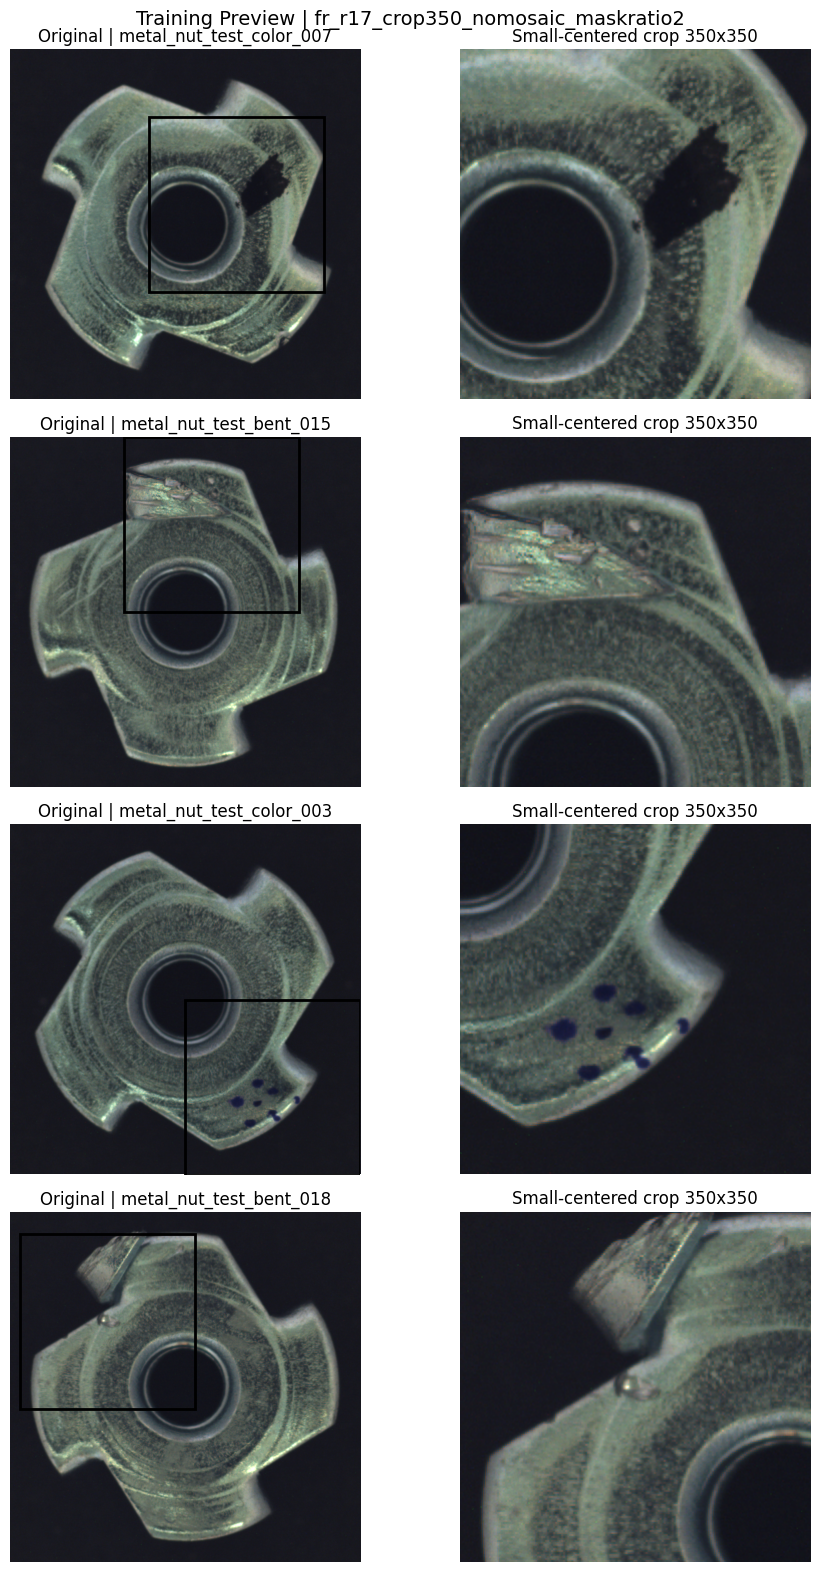

training preview saved = /kaggle/working/yolo_fast_research/runtime/fr_r17_crop350_nomosaic_maskratio2/training_preview.png

[Training config]
{
  "data": "/kaggle/working/yolo_fast_research/runtime/fr_r17_crop350_nomosaic_maskratio2/dataset.yaml",
  "task": "segment",
  "epochs": 100,
  "imgsz": 640,
  "batch": 16,
  "workers": 2,
  "optimizer": "auto",
  "patience": 20,
  "seed": 42,
  "deterministic": true,
  "amp": true,
  "device": 0,
  "project": "/kaggle/working/yolo_fast_research/runs",
  "name": "fr_r17_crop350_nomosaic_maskratio2",
  "exist_ok": false,
  "val": true,
  "verbose": true,
  "mosaic": 0.0,
  "mask_ratio": 2
}
New https://pypi.org/project/ultralytics/8.4.136 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.128 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, clas

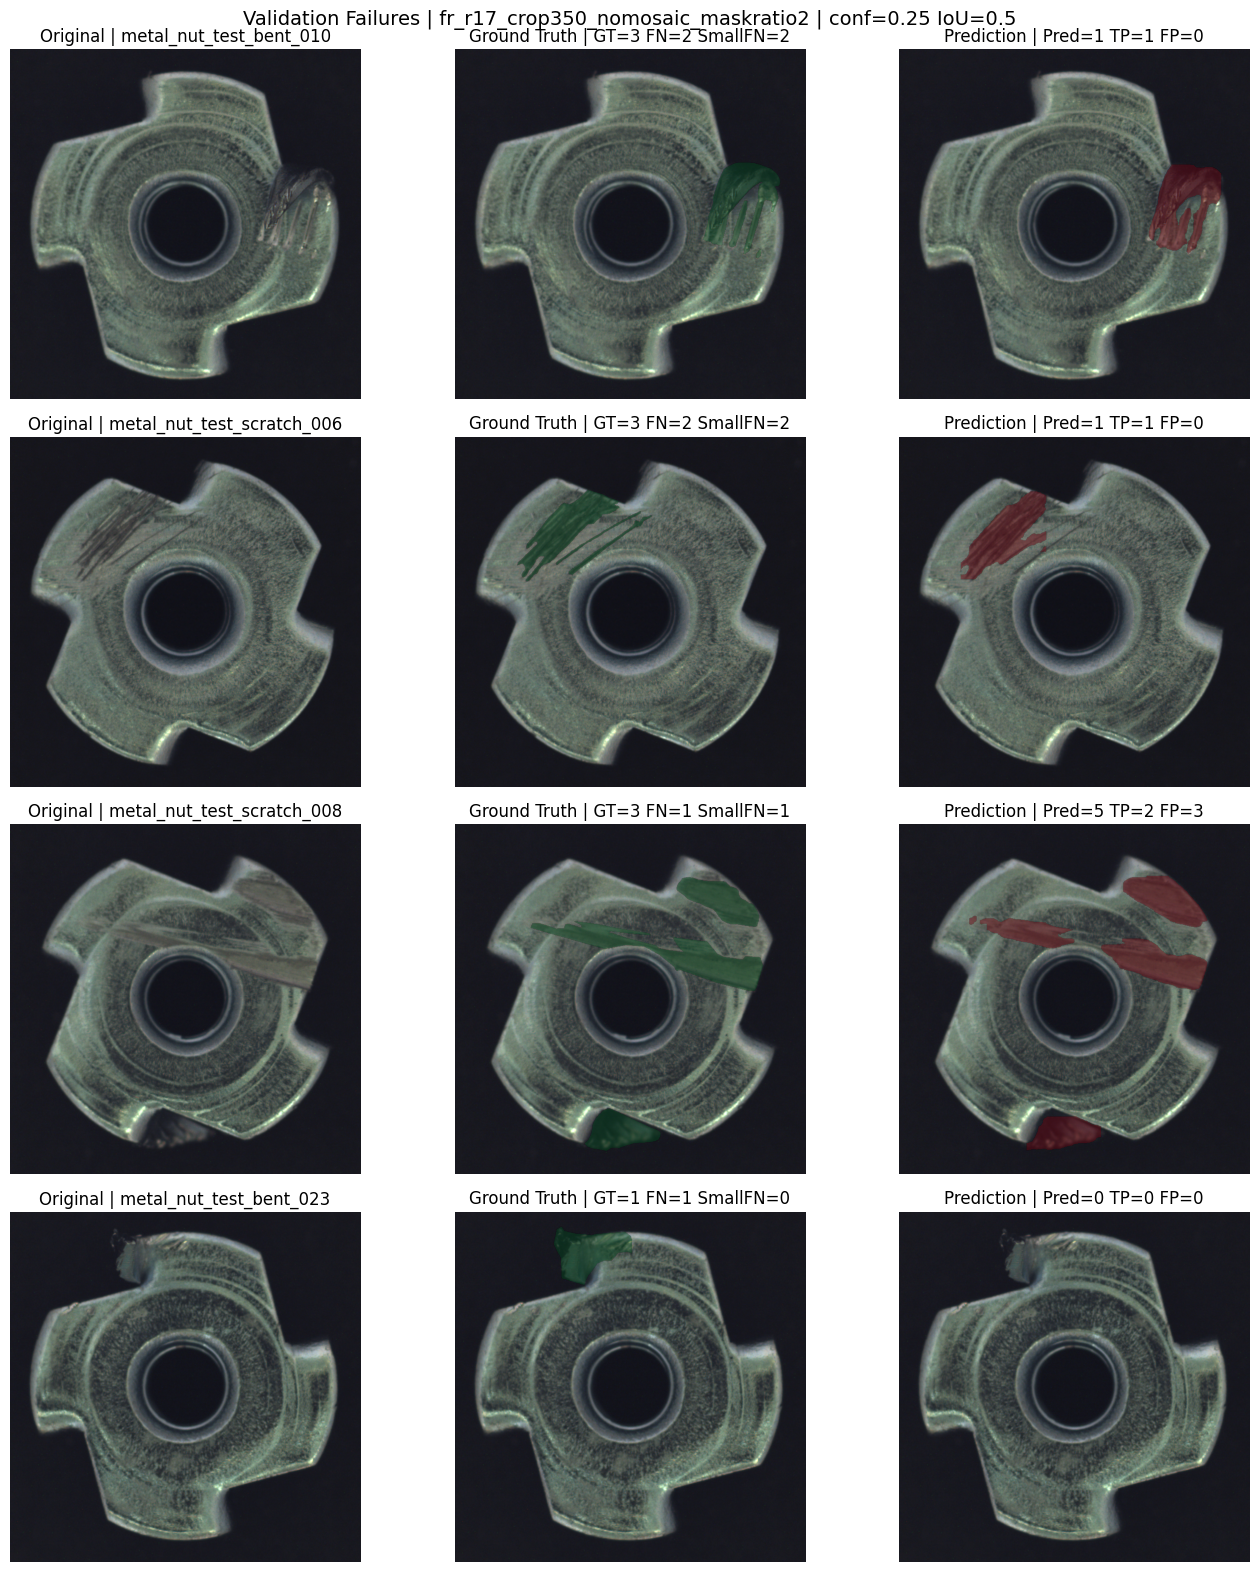

failure preview saved = /kaggle/working/yolo_fast_research/runs/fr_r17_crop350_nomosaic_maskratio2/validation_failure_preview.png

=== RESULT ===
mask_precision             = 0.8041894745001018
mask_recall                = 0.7380679462854601
mask_map50                 = 0.7635437213162777
mask_map50_95              = 0.4480250870683202
tp                         = 15
fp                         = 6
fn                         = 8
precision                  = 0.7142857142857143
recall                     = 0.6521739130434783
f1                         = 0.6818181818181819
small_recall               = 0.375
medium_recall              = 0.8571428571428571
large_recall               = 0.75
multi_recall               = 0.5714285714285714
single_recall              = 0.7777777777777778
good_negative_fp_rate      = 0.0
training_seconds           = 530.024028301
model_size_bytes           = 6015012

=== TRAIN VIEW ===
{
  "sampling_mode": "component_aware_crop",
  "sampling_multiplicity": 2,
  "

In [11]:
# ============================================================
# RUN — SETTINGS 셀만 수정하고 Run All
# ============================================================

RESULT = run_experiment(
    EXPERIMENT,
    visualization=VISUALIZATION,
)
print_result(RESULT)
print_leaderboard()

audit experiment = fr_r17_crop350_nomosaic_maskratio2
audit checkpoint = /kaggle/working/yolo_fast_research/runs/fr_r17_crop350_nomosaic_maskratio2/weights/best.pt
test configured  = False

=== fr_r17_crop350_nomosaic_maskratio2 REGION-COVERAGE AUDIT ===
{
  "experiment_id": "fr_r17_crop350_nomosaic_maskratio2",
  "strict_instance_gt_recall": 0.6521739130434783,
  "gt_component_coverage_recall_at_50": 0.7391304347826086,
  "small_gt_coverage_recall_at_50": 0.625,
  "class_aware_union_iou": 0.6646639128802103,
  "class_aware_union_gt_coverage": 0.7327787787020354,
  "class_aware_union_pred_precision": 0.877307314565798,
  "near_miss_iou_030_to_050": 1,
  "covered50_but_strict_instance_fail": 2,
  "strict_iou_threshold": 0.5,
  "coverage_threshold": 0.5,
  "val_gt_total": 23,
  "small_gt_total": 8,
  "test_used": false
}


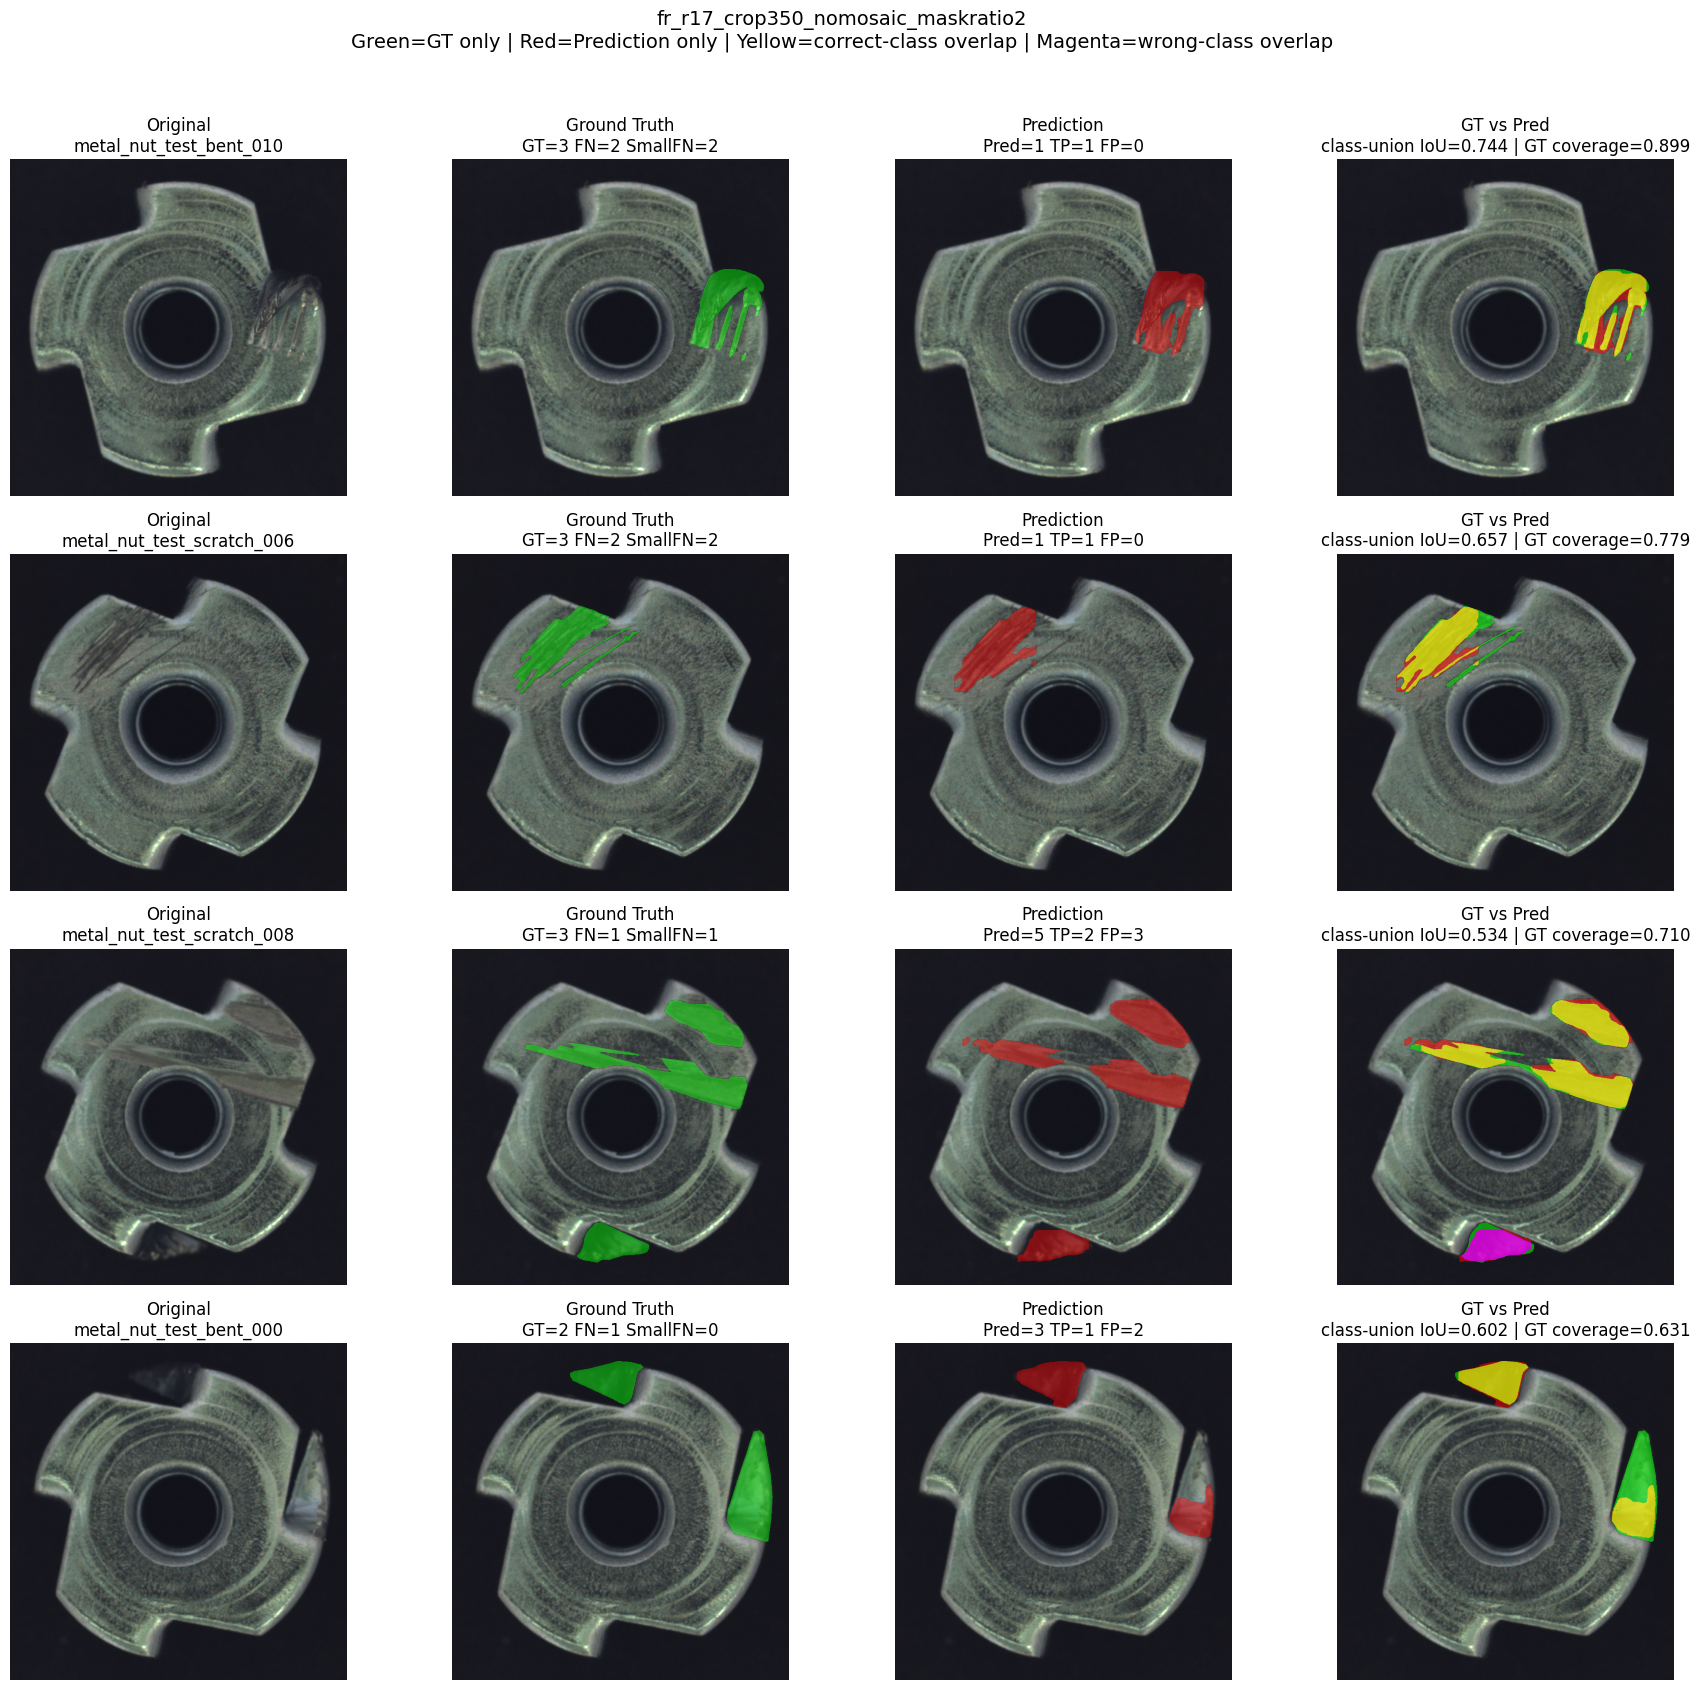


audit visualization = /kaggle/working/yolo_fast_research/runs/fr_r17_crop350_nomosaic_maskratio2/validation_region_coverage_audit.png

=== PER-GT FAILURE DETAILS ===

 metal_nut_test_bent_010
strict: TP=1 FN=2 FP=0
class-union: IoU=0.744 GT coverage=0.899 Pred precision=0.812
  GT#1 bent [small] | bestIoU=0.000 | unionCoverage=0.000 | strict=FAIL | coverage50=FAIL
  GT#2 bent [small] | bestIoU=0.063 | unionCoverage=0.862 | strict=FAIL | coverage50=PASS
  GT#3 bent [large] | bestIoU=0.698 | unionCoverage=0.912 | strict=PASS | coverage50=PASS

 metal_nut_test_scratch_006
strict: TP=1 FN=2 FP=0
class-union: IoU=0.657 GT coverage=0.779 Pred precision=0.807
  GT#1 scratch [small] | bestIoU=0.004 | unionCoverage=0.048 | strict=FAIL | coverage50=FAIL
  GT#2 scratch [small] | bestIoU=0.034 | unionCoverage=0.577 | strict=FAIL | coverage50=PASS
  GT#3 scratch [large] | bestIoU=0.694 | unionCoverage=0.879 | strict=PASS | coverage50=PASS

 metal_nut_test_scratch_008
strict: TP=2 FN=1 FP=3
class-u

In [12]:
# ============================================================
# STRICT INSTANCE vs REGION-COVERAGE AUDIT
# val only / test sealed
# ============================================================

import json
from pathlib import Path

# 현재 SETTINGS의 EXPERIMENT를 자동으로 audit.
# 예: R14를 학습한 뒤 실행하면 R14 best.pt를 평가한다.
AUDIT_EXPERIMENT_ID = str(EXPERIMENT["experiment_id"])

# SETTINGS의 기존 failure_preview_count를 그대로 사용.
AUDIT_PREVIEW_COUNT = min(
    int(VISUALIZATION["failure_preview_count"]),
    int(VISUALIZATION["max_preview_count"]),
)

AUDIT_COVERAGE_THRESHOLD = 0.50


def _safe_ratio(
    numerator: int | float,
    denominator: int | float,
) -> float:
    return float(numerator / denominator) if denominator else 0.0


def _union_masks(
    masks: list[np.ndarray],
    *,
    height: int,
    width: int,
) -> np.ndarray:
    union = np.zeros(
        (height, width),
        dtype=bool,
    )

    for mask in masks:
        union |= mask

    return union


def _same_class_prediction_union(
    predictions: list[dict],
    *,
    class_id: int,
    height: int,
    width: int,
) -> np.ndarray:
    return _union_masks(
        [pred["mask"] for pred in predictions if pred["class_id"] == class_id],
        height=height,
        width=width,
    )


def _class_aware_union_metrics(
    gt_instances,
    predictions,
    *,
    height: int,
    width: int,
) -> dict[str, float]:
    total_intersection = 0
    total_union = 0
    total_gt_pixels = 0
    total_pred_pixels = 0

    for class_id in CLASS_NAMES:
        gt_union = _union_masks(
            [gt.mask for gt in gt_instances if gt.class_id == class_id],
            height=height,
            width=width,
        )

        pred_union = _same_class_prediction_union(
            predictions,
            class_id=class_id,
            height=height,
            width=width,
        )

        intersection = int(
            np.logical_and(
                gt_union,
                pred_union,
            ).sum()
        )

        union = int(
            np.logical_or(
                gt_union,
                pred_union,
            ).sum()
        )

        total_intersection += intersection
        total_union += union
        total_gt_pixels += int(gt_union.sum())
        total_pred_pixels += int(pred_union.sum())

    return {
        "iou": _safe_ratio(
            total_intersection,
            total_union,
        ),
        "gt_coverage": _safe_ratio(
            total_intersection,
            total_gt_pixels,
        ),
        "pred_precision": _safe_ratio(
            total_intersection,
            total_pred_pixels,
        ),
    }


def _binary_union_metrics(
    gt_instances,
    predictions,
    *,
    height: int,
    width: int,
) -> dict[str, float]:
    gt_union = _union_masks(
        [gt.mask for gt in gt_instances],
        height=height,
        width=width,
    )

    pred_union = _union_masks(
        [pred["mask"] for pred in predictions],
        height=height,
        width=width,
    )

    intersection = int(
        np.logical_and(
            gt_union,
            pred_union,
        ).sum()
    )

    union = int(
        np.logical_or(
            gt_union,
            pred_union,
        ).sum()
    )

    return {
        "iou": _safe_ratio(
            intersection,
            union,
        ),
        "gt_coverage": _safe_ratio(
            intersection,
            int(gt_union.sum()),
        ),
        "pred_precision": _safe_ratio(
            intersection,
            int(pred_union.sum()),
        ),
    }


def _gt_component_audit(
    gt_instances,
    predictions,
    *,
    height: int,
    width: int,
):
    rows = []

    for gt_index, gt in enumerate(gt_instances):
        same_class_predictions = [pred for pred in predictions if pred["class_id"] == gt.class_id]

        # 기존 strict diagnostic과 동일한
        # single-prediction best IoU 확인.
        best_iou = 0.0
        best_confidence = None

        for pred in same_class_predictions:
            iou = mask_iou(
                gt.mask,
                pred["mask"],
            )

            if iou > best_iou:
                best_iou = iou
                best_confidence = pred["confidence"]

        # 같은 class prediction 전체를 union하여
        # split / merge 상황에서도 GT spatial coverage를 확인.
        same_class_union = _same_class_prediction_union(
            predictions,
            class_id=gt.class_id,
            height=height,
            width=width,
        )

        intersection = int(
            np.logical_and(
                gt.mask,
                same_class_union,
            ).sum()
        )

        gt_pixels = int(gt.mask.sum())

        union_coverage = _safe_ratio(
            intersection,
            gt_pixels,
        )

        rows.append(
            {
                "gt_index": gt_index,
                "class_id": gt.class_id,
                "class_name": CLASS_NAMES[gt.class_id],
                "area_ratio": gt.area_ratio,
                "size_group": (
                    "small"
                    if gt.area_ratio <= VAL_SMALL_MAX
                    else ("medium" if gt.area_ratio <= VAL_MEDIUM_MAX else "large")
                ),
                "best_single_pred_iou": best_iou,
                "best_pred_confidence": best_confidence,
                "same_class_union_coverage": union_coverage,
                "strict_iou_pass": (best_iou >= MATCH_IOU_THRESHOLD),
                "coverage50_pass": (union_coverage >= AUDIT_COVERAGE_THRESHOLD),
            }
        )

    return rows


# ============================================================
# Load selected experiment best.pt
# ============================================================

best_pt = RUNS_ROOT / AUDIT_EXPERIMENT_ID / "weights" / "best.pt"

assert best_pt.is_file(), f"best.pt not found: {best_pt}"

print(
    "audit experiment =",
    AUDIT_EXPERIMENT_ID,
)
print(
    "audit checkpoint =",
    best_pt,
)
print(
    "test configured  = False",
)

audit_model = YOLO(str(best_pt))


# ============================================================
# Validation-only audit
# ============================================================

audit_samples = []

strict_gt_total = 0
strict_gt_matched = 0

coverage_gt_total = 0
coverage_gt_matched = 0

small_gt_total = 0
small_coverage_matched = 0

near_miss_count = 0
covered_but_strict_fail_count = 0

dataset_class_intersection = 0
dataset_class_union = 0
dataset_class_gt_pixels = 0
dataset_class_pred_pixels = 0


for record in val_records:
    gt_instances = VAL_GT[record.sample_id]

    predictions = predict_record(
        audit_model,
        record=record,
        imgsz=int(EXPERIMENT["imgsz"]),
        device=int(EXPERIMENT["device"]),
    )

    matched_gt, matched_pred = greedy_class_aware_match(
        gt_instances,
        predictions,
    )

    component_rows = _gt_component_audit(
        gt_instances,
        predictions,
        height=record.image_height,
        width=record.image_width,
    )

    class_union = _class_aware_union_metrics(
        gt_instances,
        predictions,
        height=record.image_height,
        width=record.image_width,
    )

    binary_union = _binary_union_metrics(
        gt_instances,
        predictions,
        height=record.image_height,
        width=record.image_width,
    )

    # Dataset-level class-aware union metric 누적.
    for class_id in CLASS_NAMES:
        gt_class_union = _union_masks(
            [gt.mask for gt in gt_instances if gt.class_id == class_id],
            height=record.image_height,
            width=record.image_width,
        )

        pred_class_union = _same_class_prediction_union(
            predictions,
            class_id=class_id,
            height=record.image_height,
            width=record.image_width,
        )

        dataset_class_intersection += int(
            np.logical_and(
                gt_class_union,
                pred_class_union,
            ).sum()
        )

        dataset_class_union += int(
            np.logical_or(
                gt_class_union,
                pred_class_union,
            ).sum()
        )

        dataset_class_gt_pixels += int(gt_class_union.sum())

        dataset_class_pred_pixels += int(pred_class_union.sum())

    strict_gt_total += len(gt_instances)

    strict_gt_matched += len(matched_gt)

    for component in component_rows:
        coverage_gt_total += 1

        if component["coverage50_pass"]:
            coverage_gt_matched += 1

        if component["size_group"] == "small":
            small_gt_total += 1

            if component["coverage50_pass"]:
                small_coverage_matched += 1

        if (
            not component["strict_iou_pass"]
            and 0.30 <= component["best_single_pred_iou"] < MATCH_IOU_THRESHOLD
        ):
            near_miss_count += 1

        if not component["strict_iou_pass"] and component["coverage50_pass"]:
            covered_but_strict_fail_count += 1

    fn = len(gt_instances) - len(matched_gt)

    fp = len(predictions) - len(matched_pred)

    # 실패가 없는 validation sample은
    # failure preview 대상에서 제외한다.
    if fn == 0 and fp == 0:
        continue

    gt_union = _union_masks(
        [gt.mask for gt in gt_instances],
        height=record.image_height,
        width=record.image_width,
    )

    pred_union = _union_masks(
        [pred["mask"] for pred in predictions],
        height=record.image_height,
        width=record.image_width,
    )

    small_fn = sum(
        1
        for gt_index, gt in enumerate(gt_instances)
        if (gt.area_ratio <= VAL_SMALL_MAX and gt_index not in matched_gt)
    )

    audit_samples.append(
        {
            "sample_id": (record.sample_id),
            "image_path": (record.image_path),
            "gt_instances": (gt_instances),
            "predictions": (predictions),
            "gt_union": (gt_union),
            "pred_union": (pred_union),
            "component_rows": (component_rows),
            "strict_tp": len(matched_gt),
            "strict_fn": fn,
            "strict_fp": fp,
            "small_fn": small_fn,
            "class_union": (class_union),
            "binary_union": (binary_union),
        }
    )


# Small FN이 있는 failure를 우선 표시.
audit_samples.sort(
    key=lambda item: (
        -int(item["small_fn"] > 0),
        -item["small_fn"],
        -item["strict_fn"],
        -item["strict_fp"],
        item["sample_id"],
    )
)


# ============================================================
# Dataset-level summary
# ============================================================

dataset_summary = {
    "experiment_id": (AUDIT_EXPERIMENT_ID),
    # 기존 strict instance metric.
    "strict_instance_gt_recall": (
        _safe_ratio(
            strict_gt_matched,
            strict_gt_total,
        )
    ),
    # Same-class prediction union이
    # GT pixel의 50% 이상을 덮었는지.
    "gt_component_coverage_recall_at_50": (
        _safe_ratio(
            coverage_gt_matched,
            coverage_gt_total,
        )
    ),
    "small_gt_coverage_recall_at_50": (
        _safe_ratio(
            small_coverage_matched,
            small_gt_total,
        )
    ),
    # Instance split / merge를 무시하되
    # class는 유지하는 pixel-level metric.
    "class_aware_union_iou": (
        _safe_ratio(
            dataset_class_intersection,
            dataset_class_union,
        )
    ),
    "class_aware_union_gt_coverage": (
        _safe_ratio(
            dataset_class_intersection,
            dataset_class_gt_pixels,
        )
    ),
    "class_aware_union_pred_precision": (
        _safe_ratio(
            dataset_class_intersection,
            dataset_class_pred_pixels,
        )
    ),
    "near_miss_iou_030_to_050": (near_miss_count),
    "covered50_but_strict_instance_fail": (covered_but_strict_fail_count),
    "strict_iou_threshold": (MATCH_IOU_THRESHOLD),
    "coverage_threshold": (AUDIT_COVERAGE_THRESHOLD),
    "val_gt_total": (strict_gt_total),
    "small_gt_total": (small_gt_total),
    "test_used": False,
}


print(f"\n=== {AUDIT_EXPERIMENT_ID} REGION-COVERAGE AUDIT ===")

print(
    json.dumps(
        dataset_summary,
        indent=2,
        ensure_ascii=False,
    )
)


# ============================================================
# 4-column class-aware visual audit
#
# Original | Ground Truth | Prediction | GT vs Pred
#
# GT vs Pred overlay:
#
# GREEN
#   GT only
#
# RED
#   Prediction only
#
# YELLOW
#   GT와 Prediction이 겹치고 class도 동일
#
# MAGENTA
#   위치는 GT와 겹치지만 class가 다름
# ============================================================

selected = audit_samples[:AUDIT_PREVIEW_COUNT]

if selected:
    figure, axes = plt.subplots(
        len(selected),
        4,
        figsize=(
            18,
            4.3 * len(selected),
        ),
        squeeze=False,
    )

    for row_index, sample in enumerate(selected):
        image_bgr = cv2.imread(
            str(sample["image_path"]),
            cv2.IMREAD_COLOR,
        )

        if image_bgr is None:
            raise FileNotFoundError(sample["image_path"])

        image_rgb = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB,
        )

        gt_union = sample["gt_union"]

        pred_union = sample["pred_union"]

        # ----------------------------------------------------
        # 1) Original
        # ----------------------------------------------------

        ax = axes[
            row_index,
            0,
        ]

        ax.imshow(image_rgb)

        ax.set_title(f"Original\n{sample['sample_id']}")

        ax.axis("off")

        # ----------------------------------------------------
        # 2) Ground Truth
        # ----------------------------------------------------

        ax = axes[
            row_index,
            1,
        ]

        ax.imshow(image_rgb)

        gt_overlay = np.zeros(
            (
                *gt_union.shape,
                4,
            ),
            dtype=float,
        )

        gt_overlay[gt_union] = [
            0.0,
            1.0,
            0.0,
            0.45,
        ]

        ax.imshow(gt_overlay)

        ax.set_title(
            "Ground Truth\n"
            f"GT="
            f"{len(sample['gt_instances'])} "
            f"FN="
            f"{sample['strict_fn']} "
            f"SmallFN="
            f"{sample['small_fn']}"
        )

        ax.axis("off")

        # ----------------------------------------------------
        # 3) Prediction
        # ----------------------------------------------------

        ax = axes[
            row_index,
            2,
        ]

        ax.imshow(image_rgb)

        pred_overlay = np.zeros(
            (
                *pred_union.shape,
                4,
            ),
            dtype=float,
        )

        pred_overlay[pred_union] = [
            1.0,
            0.0,
            0.0,
            0.45,
        ]

        ax.imshow(pred_overlay)

        ax.set_title(
            "Prediction\n"
            f"Pred="
            f"{len(sample['predictions'])} "
            f"TP="
            f"{sample['strict_tp']} "
            f"FP="
            f"{sample['strict_fp']}"
        )

        ax.axis("off")

        # ----------------------------------------------------
        # 4) Class-aware GT vs Prediction
        # ----------------------------------------------------

        ax = axes[
            row_index,
            3,
        ]

        ax.imshow(image_rgb)

        # 같은 class끼리 실제로 겹치는 pixel.
        same_class_overlap = np.zeros_like(
            gt_union,
            dtype=bool,
        )

        for class_id in CLASS_NAMES:
            gt_class_union = _union_masks(
                [gt.mask for gt in sample["gt_instances"] if (gt.class_id == class_id)],
                height=(gt_union.shape[0]),
                width=(gt_union.shape[1]),
            )

            pred_class_union = _same_class_prediction_union(
                sample["predictions"],
                class_id=class_id,
                height=(gt_union.shape[0]),
                width=(gt_union.shape[1]),
            )

            same_class_overlap |= np.logical_and(
                gt_class_union,
                pred_class_union,
            )

        # Class는 무시하고 위치상 겹치는 모든 pixel.
        any_spatial_overlap = np.logical_and(
            gt_union,
            pred_union,
        )

        # 위치는 겹치지만 올바른 class overlap은 아닌 영역.
        wrong_class_overlap = np.logical_and(
            any_spatial_overlap,
            ~same_class_overlap,
        )

        # 어떤 prediction도 덮지 않은 GT 영역.
        gt_only = np.logical_and(
            gt_union,
            ~pred_union,
        )

        # 어떤 GT와도 겹치지 않은 prediction 영역.
        pred_only = np.logical_and(
            pred_union,
            ~gt_union,
        )

        combined = np.zeros(
            (
                *gt_union.shape,
                4,
            ),
            dtype=float,
        )

        # GREEN = GT only
        combined[gt_only] = [
            0.0,
            1.0,
            0.0,
            0.55,
        ]

        # RED = Prediction only
        combined[pred_only] = [
            1.0,
            0.0,
            0.0,
            0.55,
        ]

        # YELLOW = correct-class overlap
        combined[same_class_overlap] = [
            1.0,
            1.0,
            0.0,
            0.70,
        ]

        # MAGENTA = spatial overlap but wrong class
        combined[wrong_class_overlap] = [
            1.0,
            0.0,
            1.0,
            0.75,
        ]

        ax.imshow(combined)

        ax.set_title(
            "GT vs Pred\n"
            f"class-union IoU="
            f"{sample['class_union']['iou']:.3f} | "
            f"GT coverage="
            f"{sample['class_union']['gt_coverage']:.3f}"
        )

        ax.axis("off")

    # --------------------------------------------------------
    # Figure title / legend
    # --------------------------------------------------------

    figure.suptitle(
        (
            f"{AUDIT_EXPERIMENT_ID}\n"
            "Green=GT only | "
            "Red=Prediction only | "
            "Yellow=correct-class overlap | "
            "Magenta=wrong-class overlap"
        ),
        fontsize=14,
    )

    figure.tight_layout(
        rect=[
            0.0,
            0.0,
            1.0,
            0.96,
        ]
    )

    audit_png = RUNS_ROOT / AUDIT_EXPERIMENT_ID / "validation_region_coverage_audit.png"

    figure.savefig(
        audit_png,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

    plt.close(figure)

    print(
        "\naudit visualization =",
        audit_png,
    )


# ============================================================
# Per-GT failure details
# ============================================================

print("\n=== PER-GT FAILURE DETAILS ===")

for sample in selected:
    print(
        "\n",
        sample["sample_id"],
    )

    print(
        "strict:",
        f"TP={sample['strict_tp']}",
        f"FN={sample['strict_fn']}",
        f"FP={sample['strict_fp']}",
    )

    print(
        "class-union:",
        f"IoU={sample['class_union']['iou']:.3f}",
        f"GT coverage={sample['class_union']['gt_coverage']:.3f}",
        f"Pred precision={sample['class_union']['pred_precision']:.3f}",
    )

    for component in sample["component_rows"]:
        print(
            "  "
            f"GT#"
            f"{component['gt_index'] + 1} "
            f"{component['class_name']} "
            f"[{component['size_group']}] | "
            f"bestIoU="
            f"{component['best_single_pred_iou']:.3f} | "
            f"unionCoverage="
            f"{component['same_class_union_coverage']:.3f} | "
            f"strict="
            f"{'PASS' if component['strict_iou_pass'] else 'FAIL'} | "
            f"coverage50="
            f"{'PASS' if component['coverage50_pass'] else 'FAIL'}"
        )


# ============================================================
# Save audit JSON
# ============================================================

audit_json = RUNS_ROOT / AUDIT_EXPERIMENT_ID / "validation_region_coverage_audit.json"

audit_json.write_text(
    json.dumps(
        dataset_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print(
    "\naudit JSON =",
    audit_json,
)

print("test used  = False")

In [13]:
%%bash

cd /kaggle/working

zip -r SmartFactory_YOLO_Fast_Research_2026-08-31_pre_C4-2C_OFFICIAL_SLIM.zip \
  yolo_fast_research \
  -x "*/weights/epoch*.pt" \
     "*/__pycache__/*" \
     "*.pyc"

echo
echo "=== FILE INFO ==="
ls -lh SmartFactory_YOLO_Fast_Research_2026-08-31_pre_C4-2C_OFFICIAL_SLIM.zip

echo
echo "=== SHA256 ==="
sha256sum SmartFactory_YOLO_Fast_Research_2026-08-31_pre_C4-2C_OFFICIAL_SLIM.zip

  adding: yolo_fast_research/ (stored 0%)
  adding: yolo_fast_research/runtime/ (stored 0%)
  adding: yolo_fast_research/runtime/fr_r16_yolo11s_crop350_nomosaic/ (stored 0%)
  adding: yolo_fast_research/runtime/fr_r16_yolo11s_crop350_nomosaic/images/ (stored 0%)
  adding: yolo_fast_research/runtime/fr_r16_yolo11s_crop350_nomosaic/images/train_crops/ (stored 0%)
  adding: yolo_fast_research/runtime/fr_r16_yolo11s_crop350_nomosaic/images/train_crops/metal_nut_test_bent_012__small_center_crop350.png (deflated 1%)
  adding: yolo_fast_research/runtime/fr_r16_yolo11s_crop350_nomosaic/images/train_crops/metal_nut_test_scratch_005__small_center_crop350.png (deflated 1%)
  adding: yolo_fast_research/runtime/fr_r16_yolo11s_crop350_nomosaic/images/train_crops/metal_nut_test_bent_007__small_center_crop350.png (deflated 0%)
  adding: yolo_fast_research/runtime/fr_r16_yolo11s_crop350_nomosaic/images/train_crops/metal_nut_test_bent_018__small_center_crop350.png (deflated 0%)
  adding: yolo_fast_resea